In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset
import SimpleITK as sitk
from scipy.ndimage import uniform_filter, binary_closing, binary_dilation, label, center_of_mass, distance_transform_edt
from skimage.morphology import remove_small_objects
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from cuml.manifold import TSNE, UMAP
from joblib import Parallel, delayed
from tqdm import tqdm

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
def anisotropic_diffusion(img, n_iter = 20, kappa = 0.1, gamma = 0.1):
    img = img if isinstance(img, np.ndarray) else img.numpy()
    sitk_img = sitk.GetImageFromArray(img.astype(np.float32))
    filt = sitk.GradientAnisotropicDiffusionImageFilter()
    filt.SetNumberOfIterations(n_iter)
    filt.SetConductanceParameter(kappa)
    filt.SetTimeStep(gamma)
    result = filt.Execute(sitk_img)
    return sitk.GetArrayFromImage(result)

def filter_shadow_by_distance(shadow_mask, T_mask, T_D=10, min_shadow_size=20):
    """
    Improved shadow filtering:
      1. remove_small_objects to eliminate tiny noise CCs
      2. Accept CC if its CLOSEST pixel to the target boundary is within T_D
         (boundary distance, not centroid-to-centroid distance)
    """
    # Step 1: remove small spurious CCs
    cleaned = remove_small_objects(shadow_mask.astype(bool), min_size=min_shadow_size)
    
    # Step 2: compute distance transform from target boundary
    # distance_transform_edt on the *inverted* target mask gives
    # each pixel its distance to the nearest target pixel
    dist_from_target = distance_transform_edt(1 - T_mask)
    
    labeled, n = label(cleaned)
    if n == 0:
        return np.zeros_like(shadow_mask)
    
    best_mask = np.zeros_like(shadow_mask)
    
    for region_id in range(1, n + 1):
        region = (labeled == region_id)
        # minimum distance from any pixel in this CC to the target boundary
        min_dist = dist_from_target[region].min()
        if min_dist < T_D:
            best_mask |= region
    
    return best_mask

def zhao_segmentation_v2(img):
    I_pm = anisotropic_diffusion(img)
    I_n = readjust_intensity(I_pm)
    T_b, S_b = find_target_and_shadow_mask(I_n, high = 90, low = 35)
    T_c, S_c = counting_filter(T_b, window_size = 5, threshold = 15), counting_filter(S_b, window_size = 5, threshold = 15)
    T_dilated, S_closing = binary_dilation(T_c, structure = structing_ele(shape = 5)).astype(int), binary_closing(S_c, structure = structing_ele(shape = 5)).astype(int)
    
    T_mask = find_largest_connected_component(T_dilated)
    if T_mask.sum() == 0:
        zeros = np.zeros(img.shape, dtype=int)
        return zeros, zeros, np.ones(img.shape, dtype=int)

    S_mask = filter_shadow_by_distance(S_closing, T_mask, T_D=5, min_shadow_size=20)

    clutter = 1 - (T_mask + S_mask)
    return T_mask, S_mask, clutter

# identity mapping: no augmentations
identity = lambda x: x

class MaskedAugmentation:
    """
    Computes Zhao_v2 segmentation mask on the pre-augmentation image,
    applies augmentation, then masks the result to target+shadow only.
    
    Pipeline: log_mapped_img → compute mask → aug → apply mask
    
    Args:
        augmentation: SSRAugmentation, GaussianNoise, or any transform
                      that accepts (image, filepath) tuples
    """
    def __init__(self, augmentation, fill=np.mean, mask_cache=None):
        self.aug = augmentation
        self.fill = fill
        self.mask_cache = mask_cache

    def __call__(self, img_or_tuple):
        if isinstance(img_or_tuple, tuple):
            image, filepath = img_or_tuple
        else:
            # Can't segment without filepath context; passthrough
            return img_or_tuple
    
        # Use cached mask if available, else compute on the fly
        if self.mask_cache is not None and filepath in self.mask_cache:
            mask = self.mask_cache[filepath].astype(np.float32)
        else:
            M_target, M_shadow, _ = zhao_segmentation_v2(image)
            mask = (M_target + M_shadow).astype(np.float32)

        # Step 2: apply augmentation
        aug_result = self.aug((image, filepath))
        aug_image = aug_result[0] if isinstance(aug_result, tuple) else aug_result
        fp = aug_result[1] if isinstance(aug_result, tuple) else filepath
        
        # Step 3: apply mask + fill using augmented image statistics
        if mask.any():
            target_shadow_pixels = aug_image[mask == 1]
            fill_val = self.fill(target_shadow_pixels) if callable(self.fill) else float(self.fill)
        else:
            fill_val = 0.0

        result = aug_image * mask + fill_val * (1 - mask)

        return (result.astype(np.float32), fp)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [4]:
no_aug_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose(
        [Magnitude(), 
         LogMapping(c = 1000.0), 
         NumpyToTensor3Channel()]
    ),
    loader = mat_file_loader
)

meas_ds = datasets.DatasetFolder(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose(
        [Magnitude(), 
         LogMapping(c = 1000.0), 
         NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [5]:
synth_paths = [s[0] for s in no_aug_synth_ds.samples]

synth_mask_cache = {}
for path in tqdm(synth_paths):
    img = mat_file_loader(path)
    img = LogMapping(c=1000.0)(Magnitude()(img))
    T, S, _ = zhao_segmentation_v2(img)
    synth_mask_cache[path] = (T + S).astype(np.uint8)

meas_paths = [s[0] for s in meas_ds.samples]

meas_mask_cache = {}
for path in tqdm(meas_paths):
    img = mat_file_loader(path)
    img = LogMapping(c=1000.0)(Magnitude()(img))
    T, S, _ = zhao_segmentation_v2(img)
    meas_mask_cache[path] = (T + S).astype(np.uint8)

100%|███████████████████████████████████████████████████████████████████████████████| 1345/1345 [01:05<00:00, 20.45it/s]


In [6]:
synth_paths = [s[0] for s in no_aug_synth_ds.samples]

synth_target_cache = {}
for path in tqdm(synth_paths):
    img = mat_file_loader(path)
    img = LogMapping(c=1000.0)(Magnitude()(img))
    T, S, _ = zhao_segmentation_v2(img)
    synth_target_cache[path] = (T).astype(np.uint8)

meas_paths = [s[0] for s in meas_ds.samples]

meas_target_cache = {}
for path in tqdm(meas_paths):
    img = mat_file_loader(path)
    img = LogMapping(c=1000.0)(Magnitude()(img))
    T, S, _ = zhao_segmentation_v2(img)
    meas_target_cache[path] = (T).astype(np.uint8)

100%|███████████████████████████████████████████████████████████████████████████████| 1345/1345 [01:05<00:00, 20.48it/s]


In [7]:
seg_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions=(".mat"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation=identity, fill=0, mask_cache=synth_mask_cache),
        NumpyToTensor3Channel()
    ]),
    loader=mat_file_loader
)

seg_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation=identity, fill=0, mask_cache=meas_mask_cache),
        NumpyToTensor3Channel()
    ]),
    loader=mat_file_loader
)

seg_mean_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions=(".mat"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation=identity, fill=np.mean, mask_cache=synth_mask_cache),
        NumpyToTensor3Channel()
    ]),
    loader=mat_file_loader
)

seg_mean_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation=identity, fill=np.mean, mask_cache=meas_mask_cache),
        NumpyToTensor3Channel()
    ]),
    loader=mat_file_loader
)

seg_target_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions=(".mat"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation=identity, fill=0, mask_cache=synth_target_cache),
        NumpyToTensor3Channel()
    ]),
    loader=mat_file_loader
)

seg_target_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation=identity, fill=0, mask_cache=meas_target_cache),
        NumpyToTensor3Channel()
    ]),
    loader=mat_file_loader
)

In [9]:
train_ds = seg_target_synth_ds
test_ds = seg_target_meas_ds

ds_dict = {"train" : train_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "test": len(test_ds)}

In [9]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

train_loss = []
# val_loss = []
train_acc =[]
# val_acc = []

for i, seed in enumerate(seed_lst):
    print(f"Training Run {i}: seed {seed}")

    set_seed(seed)

    dataloaders = {
        "train": DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=12, pin_memory = True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        # "val": DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=12, pin_memory = True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }
    # load pre-trained model
    model = models.resnet18(weights = None)

    # Replace final layer for the number of classes
    model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(model.fc.in_features, len(train_ds.class_to_idx))
    )
    
    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss() # most common used nn for classification problems
    
    optimizer = optim.AdamW(model.parameters(), lr = 3e-4, weight_decay = 2e-4)
    
    scheduler = CosineAnnealingLR(optimizer, T_max = 200, eta_min = 3e-7)
    # scheduler = OneCycleLR(
    #     optimizer, 
    #     max_lr = 2.5e-4, 
    #     steps_per_epoch = len(dataloaders["train"]), 
    #     epochs = 100
    #     )
        
    # move model to GPU
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    history = {
        "train_loss": [],
        # "val_loss" : [],
        "train_acc": [],
        # "val_acc" : []
    }
    
    # Training loops
    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            print(f"First layer mean: {model.conv1.weight.data.mean():.6f}")
        for phase in ["train"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
    
            running_loss = 0.0
            running_corrects = 0 # correct predictions
    
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
    
                optimizer.zero_grad() # clear the gradient from previous iteration
    
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels) # check if output and labels match
    
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
                        # scheduler.step() # scheduler here if OneCycleLR
    
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
    
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
            
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
    
            print(f"{phase} Loss: {epoch_loss:.10f} Acc: {epoch_acc:.10f}")
    
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")
        
    print("Training complete!")
    
    train_loss.append(history["train_loss"])
    # val_loss.append(history["val_loss"])
    train_acc.append(history["train_acc"])
    # val_acc.append(history["val_acc"])
    
    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/wo_aug/target_only/rn18_seed{seed}_b16.pth"))

train_loss = np.array(train_loss)
# val_loss = np.array(val_loss)
train_acc = np.array(train_acc)
# val_acc = np.array(val_acc)

Training Run 0: seed 10
Epoch 0
First layer mean: 0.000224
train Loss: 0.5152438600 Acc: 0.8379182156
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 0.0693930578 Acc: 0.9836431227
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 0.0607350417 Acc: 0.9843866171
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 0.0406751425 Acc: 0.9925650558
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 0.0721366996 Acc: 0.9821561338
Epoch 4 LR: 0.0002995381
Epoch 5
train Loss: 0.0307131447 Acc: 0.9925650558
Epoch 5 LR: 0.0002993350
Epoch 6
train Loss: 0.0127631053 Acc: 0.9985130112
Epoch 6 LR: 0.0002990950
Epoch 7
train Loss: 0.0083776492 Acc: 0.9992565056
Epoch 7 LR: 0.0002988184
Epoch 8
train Loss: 0.0081122332 Acc: 0.9992565056
Epoch 8 LR: 0.0002985050
Epoch 9
train Loss: 0.0397557022 Acc: 0.9903345725
Epoch 9 LR: 0.0002981551
Epoch 10
train Loss: 0.0441680129 Acc: 0.9888475836
Epoch 10 LR: 0.0002977686
Epoch 11
train Loss: 0.0271446561 Acc: 0.9910780669
Epoch 11 LR: 0.0002973457
Epoch 12
train Loss: 0.0133590992

# Results

## Target + Shadow

### Fill = 0

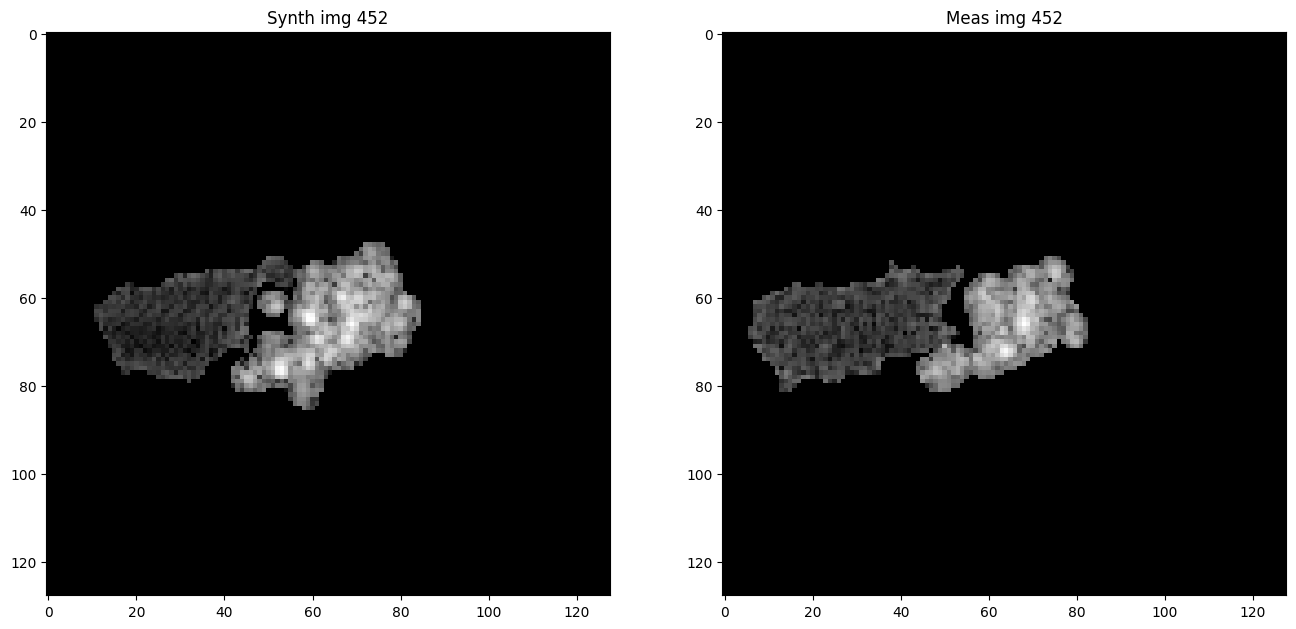

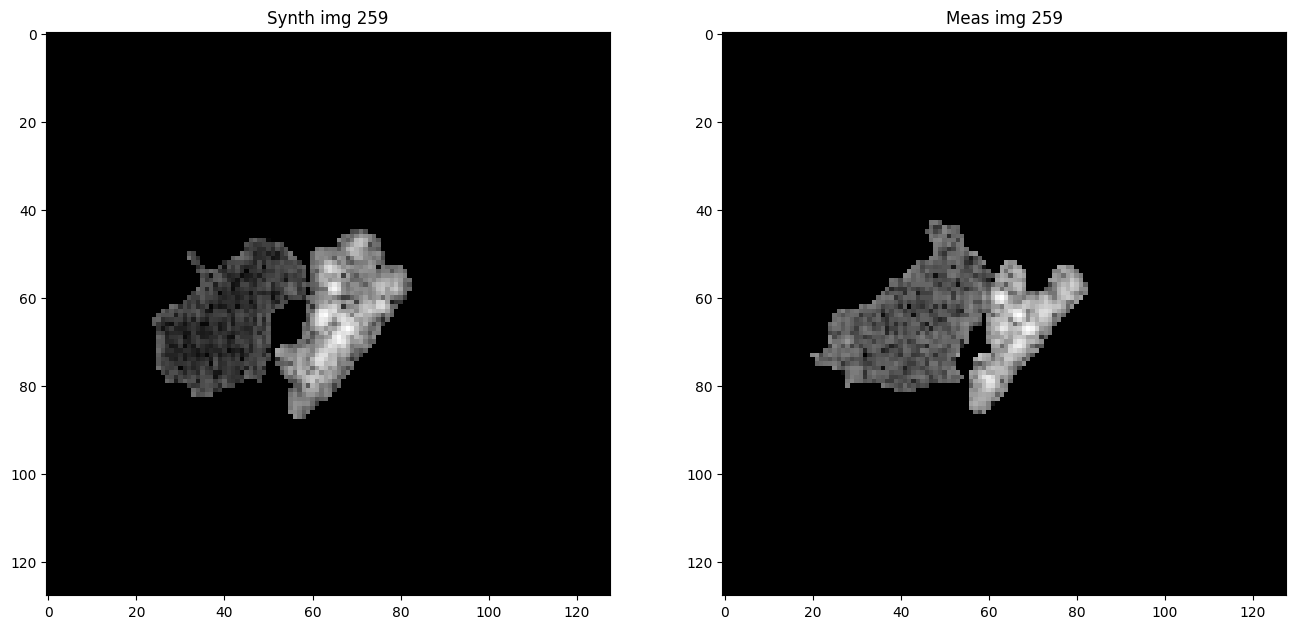

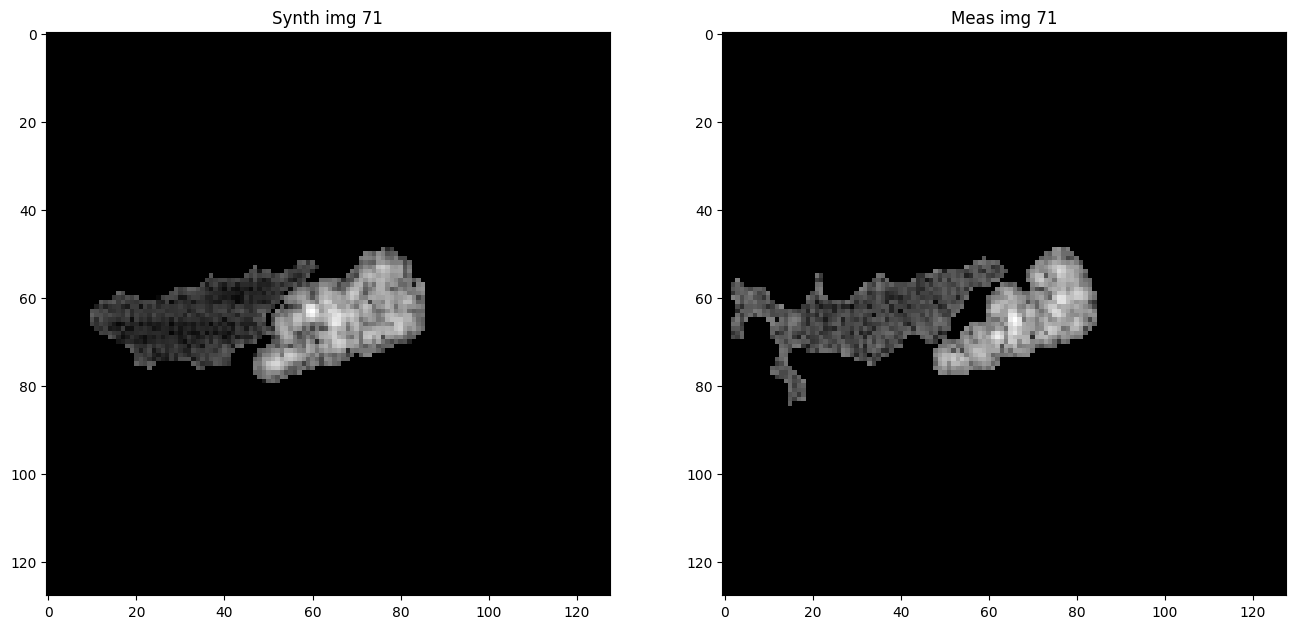

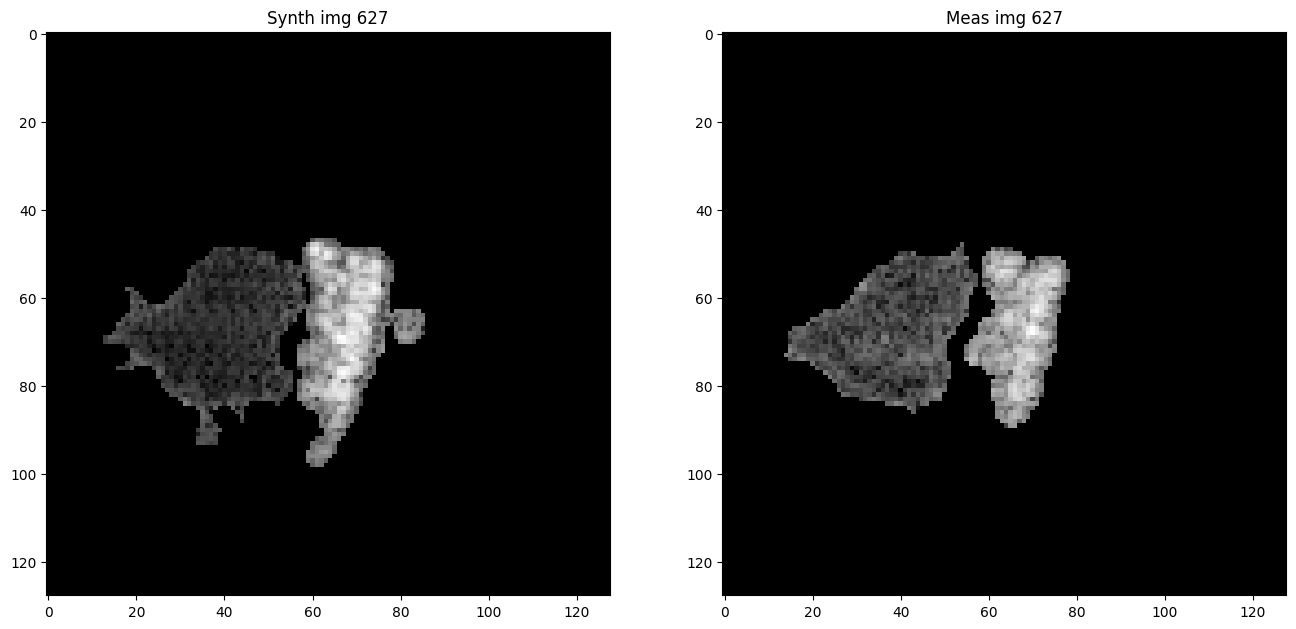

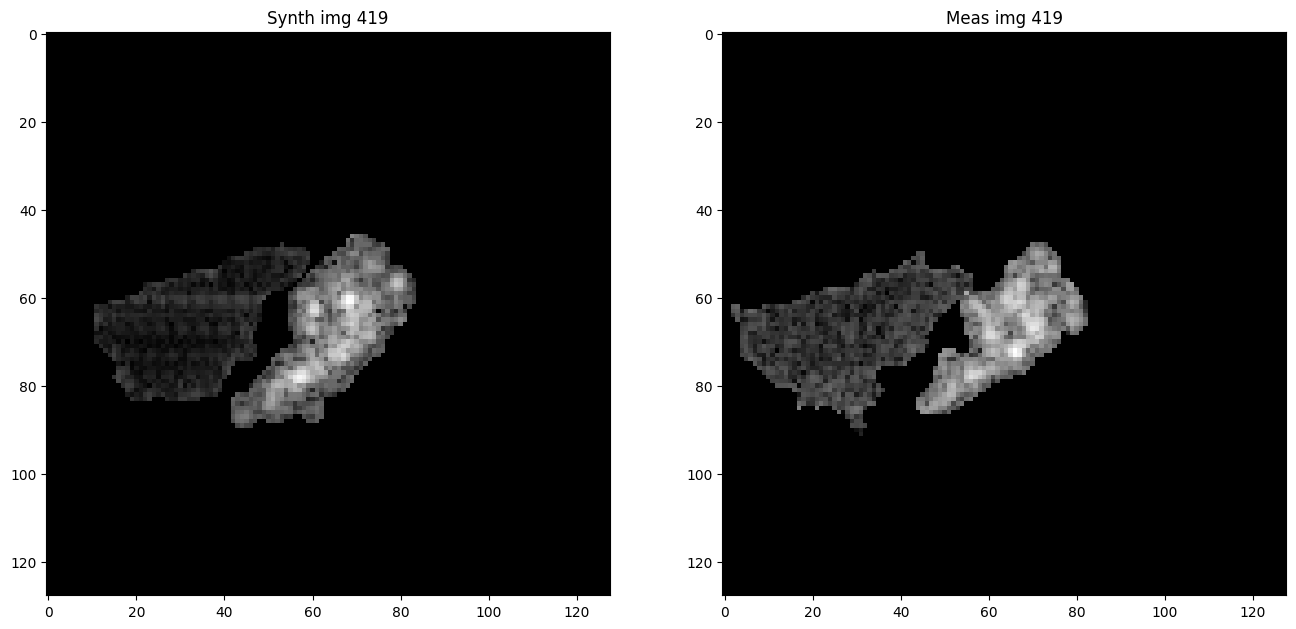

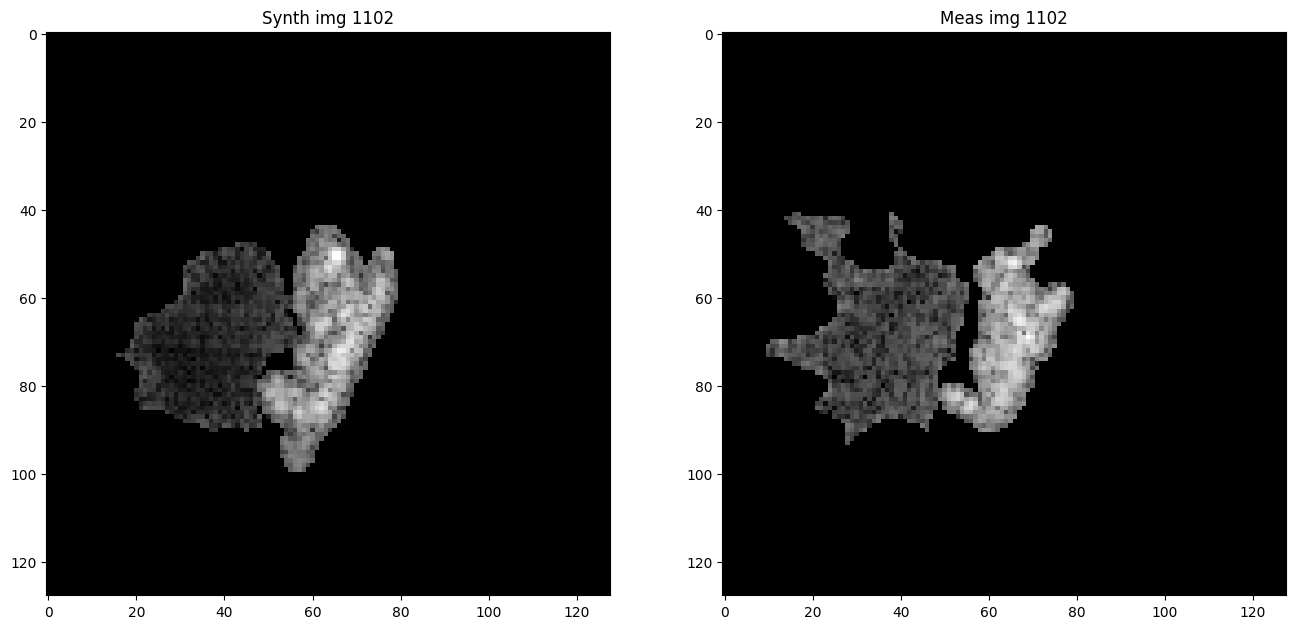

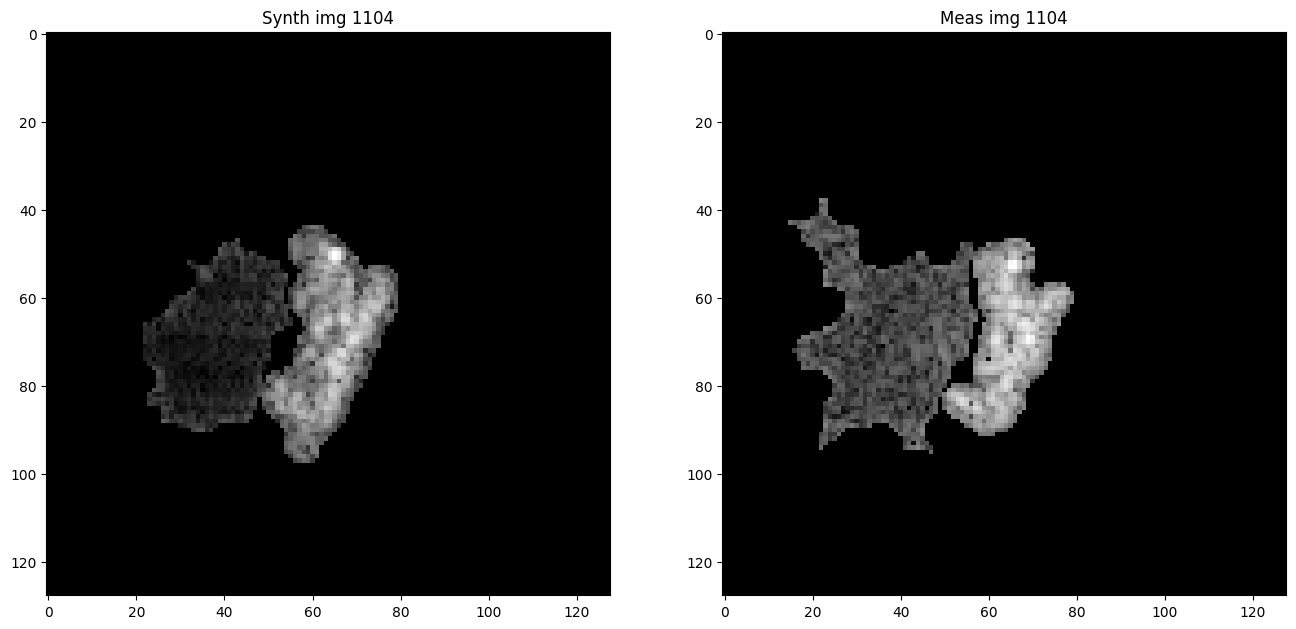

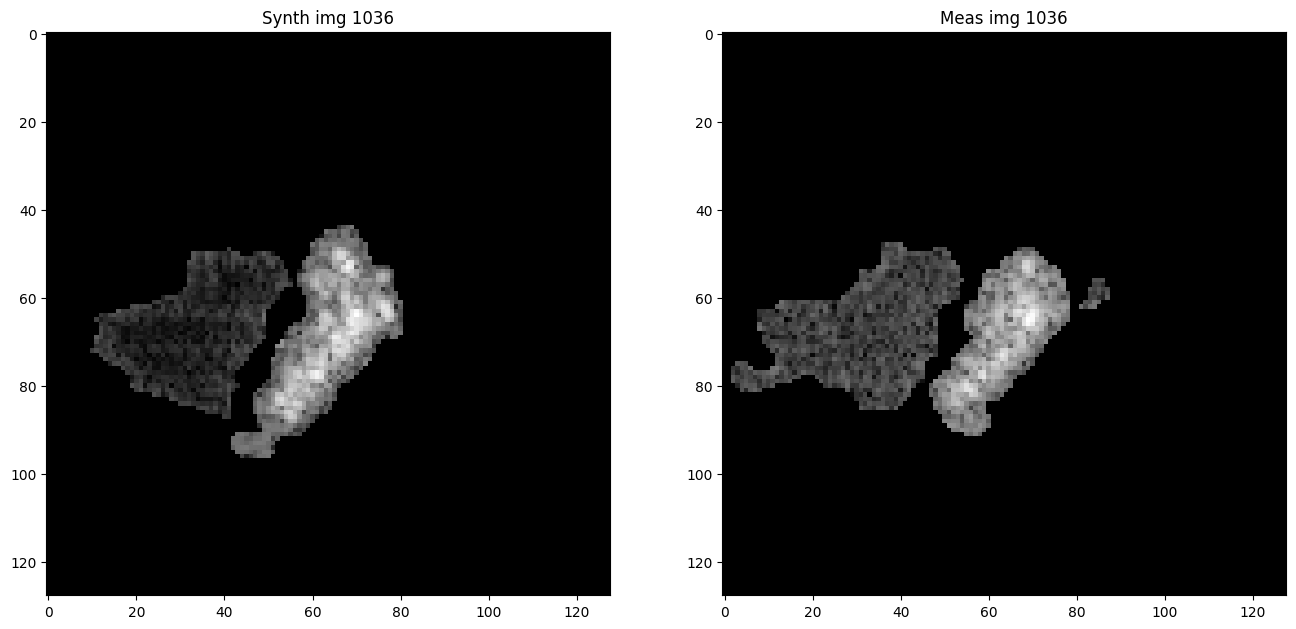

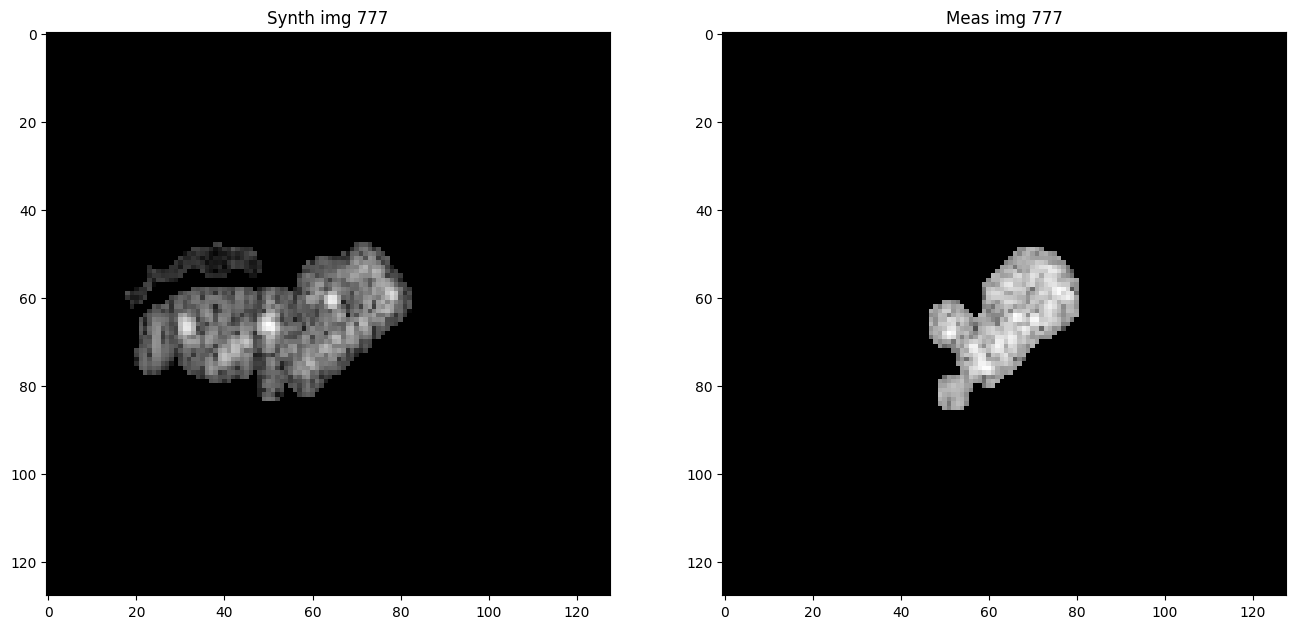

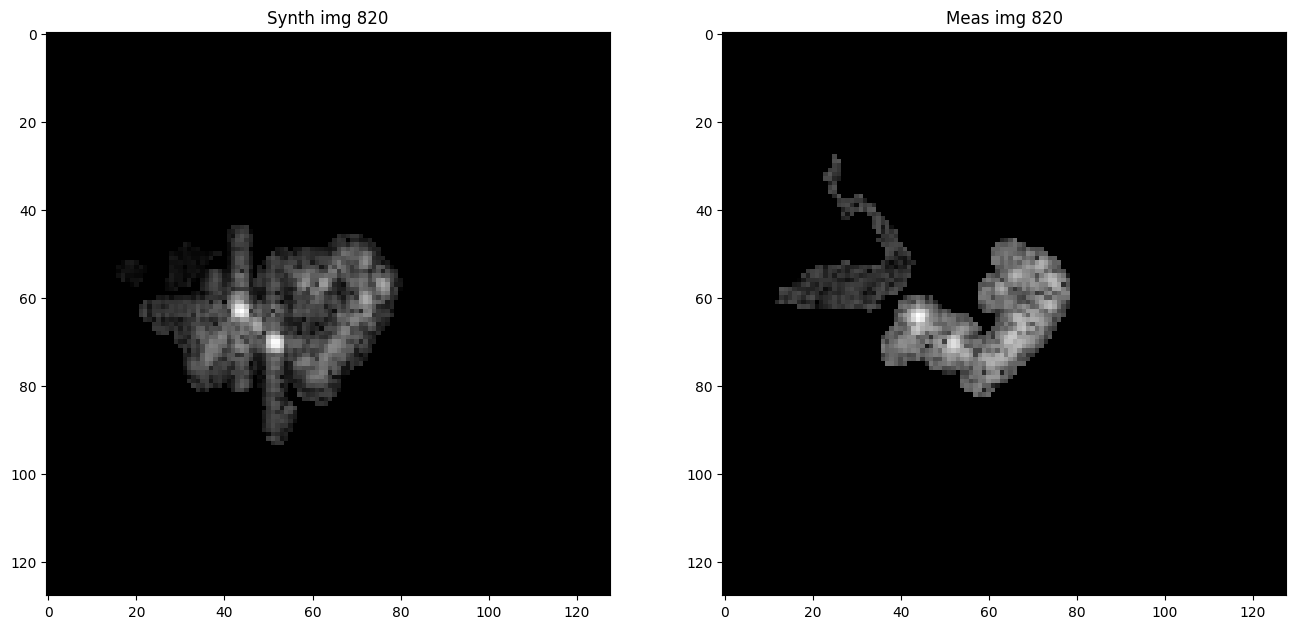

In [8]:
for i in [ 452,  259,   71,  627,  419, 1102, 1104, 1036,  777,  820]:
    synth_img = seg_synth_ds[i][0][0]
    meas_img = seg_meas_ds[i][0][0]

    fig = plt.figure(figsize = (16, 9))
    
    ax0 = fig.add_subplot(1, 2, 1)
    ax0.imshow(synth_img, vmin = 0, vmax = 1, cmap = "gray")
    ax0.set_title(f"Synth img {i}") 
    
    ax1 = fig.add_subplot(1, 2, 2)
    ax1.imshow(meas_img, vmin = 0, vmax = 1, cmap = "gray")
    ax1.set_title(f"Meas img {i}") 

    plt.show()

In [12]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: Seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/wo_aug/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(seg_meas_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0: Seed 10
Test Accuracy: 0.8126
Evaluating Run 1: Seed 42
Test Accuracy: 0.8283
Evaluating Run 2: Seed 100
Test Accuracy: 0.7911
Evaluating Run 3: Seed 123
Test Accuracy: 0.8245
Evaluating Run 4: Seed 666
Test Accuracy: 0.8000
Evaluating Run 5: Seed 777
Test Accuracy: 0.8082
Evaluating Run 6: Seed 849
Test Accuracy: 0.7933
Evaluating Run 7: Seed 1000
Test Accuracy: 0.8335
Evaluating Run 8: Seed 1111
Test Accuracy: 0.7896
Evaluating Run 9: Seed 1234
Test Accuracy: 0.8491


In [17]:
test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Min: 78.9591
Max: 84.9071
Avg, Std: 81.3011, 1.9220


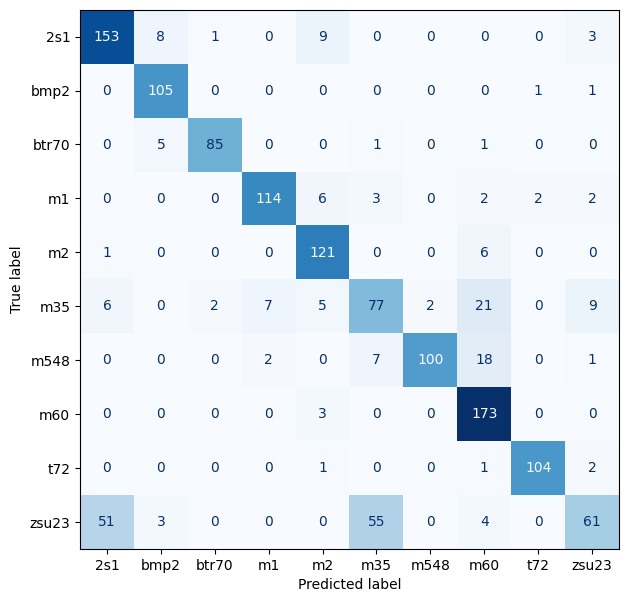

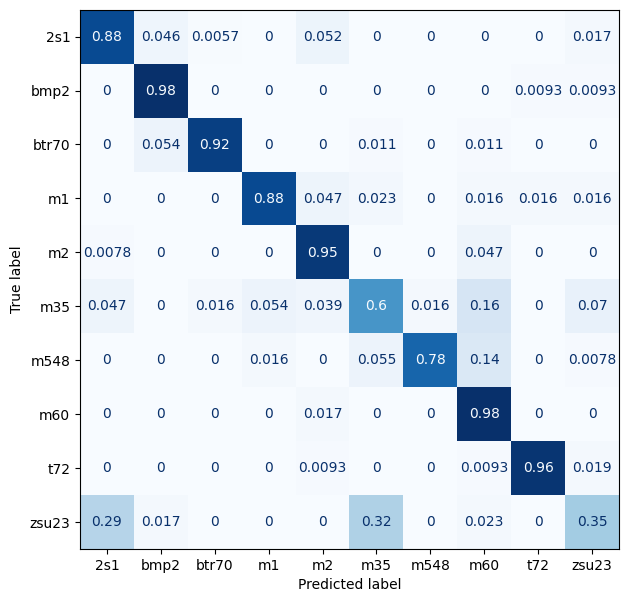

In [12]:
train_ds = seg_synth_ds
test_ds = seg_meas_ds

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Sequential(
    nn.Dropout(p = 0.4),
    nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
)

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/wo_aug/no_fill/rn18_seed10_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

labels_lst, preds_lst = [], []

with torch.no_grad():
    for inputs, labels in DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = new_model(inputs)
        _, preds = torch.max(outputs, 1)

        labels_lst.append(labels)
        preds_lst.append(preds)

_labels_all = torch.cat(labels_lst).cpu().numpy()
_preds_all = torch.cat(preds_lst).cpu().numpy()

# confusion matrix
cm = confusion_matrix(_labels_all, _preds_all)
cm_cpu  = cp.asnumpy(cm)

disp = ConfusionMatrixDisplay(cm_cpu, display_labels = train_ds.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.show()

cm_norm = confusion_matrix(_labels_all, _preds_all, normalize = "true")
cm_norm_cpu  = cp.asnumpy(cm_norm)
disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels = train_ds.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.show()

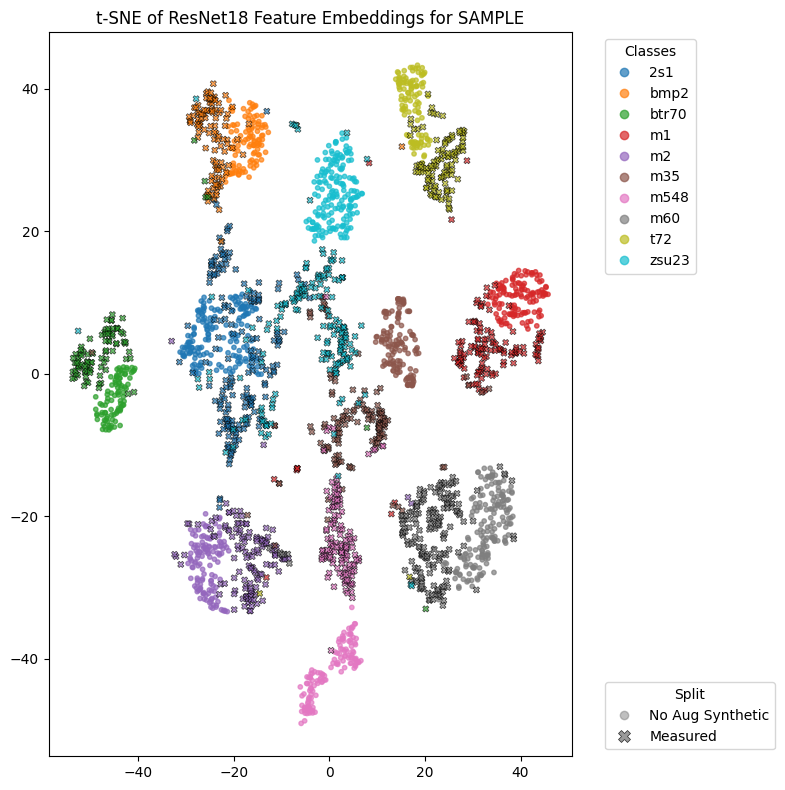

In [25]:
train_ds = seg_synth_ds
test_ds = seg_meas_ds

combined_ds = ConcatDataset([train_ds, test_ds])
combined_loader = DataLoader(combined_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True)

device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/wo_aug/no_fill/rn18_seed10_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate_method="adaptive",
    metric = "cosine"
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(train_ds), 0],
    features_2d[:len(train_ds), 1],
    c=labels_list[:len(train_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(train_ds):, 0],
    features_2d[len(train_ds):, 1],
    c=labels_list[len(train_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

[2026-05-26 19:08:02.434] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


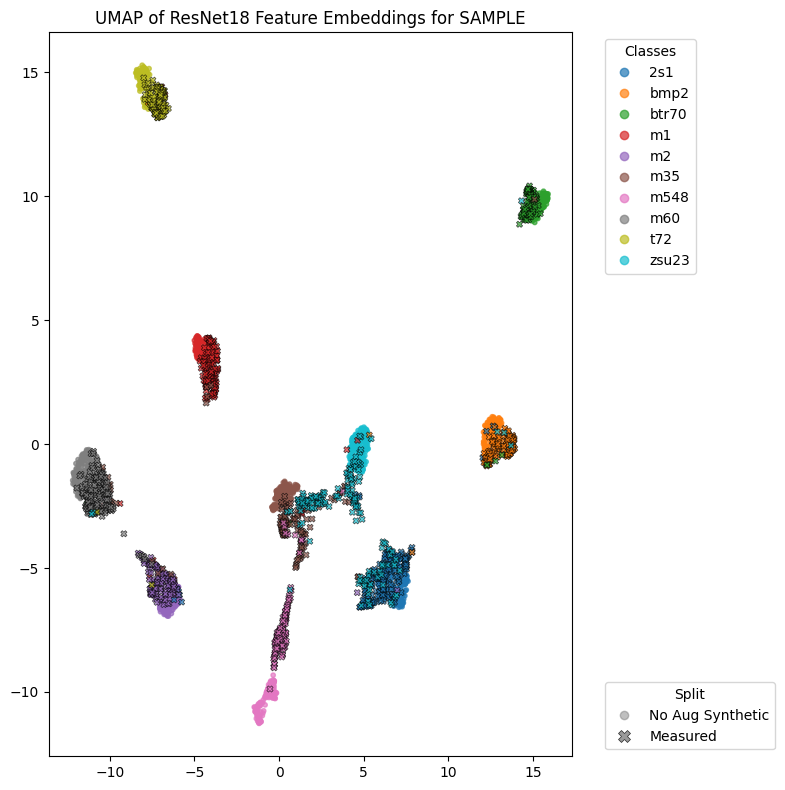

In [29]:
train_ds = seg_synth_ds
test_ds = seg_meas_ds

combined_ds = ConcatDataset([train_ds, test_ds])
combined_loader = DataLoader(combined_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True)

device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(meas_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/wo_aug/no_fill/rn18_seed10_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

reducer = UMAP(
    n_neighbors=100,
    min_dist=0.25,
    n_components=2,
    metric = "cosine"
)

features_2d_umap = reducer.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d_umap[:len(train_ds), 0],
    features_2d_umap[:len(train_ds), 1],
    c=labels_list[:len(train_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d_umap[len(train_ds):, 0],
    features_2d_umap[len(train_ds):, 1],
    c=labels_list[len(train_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

### Mean Filled

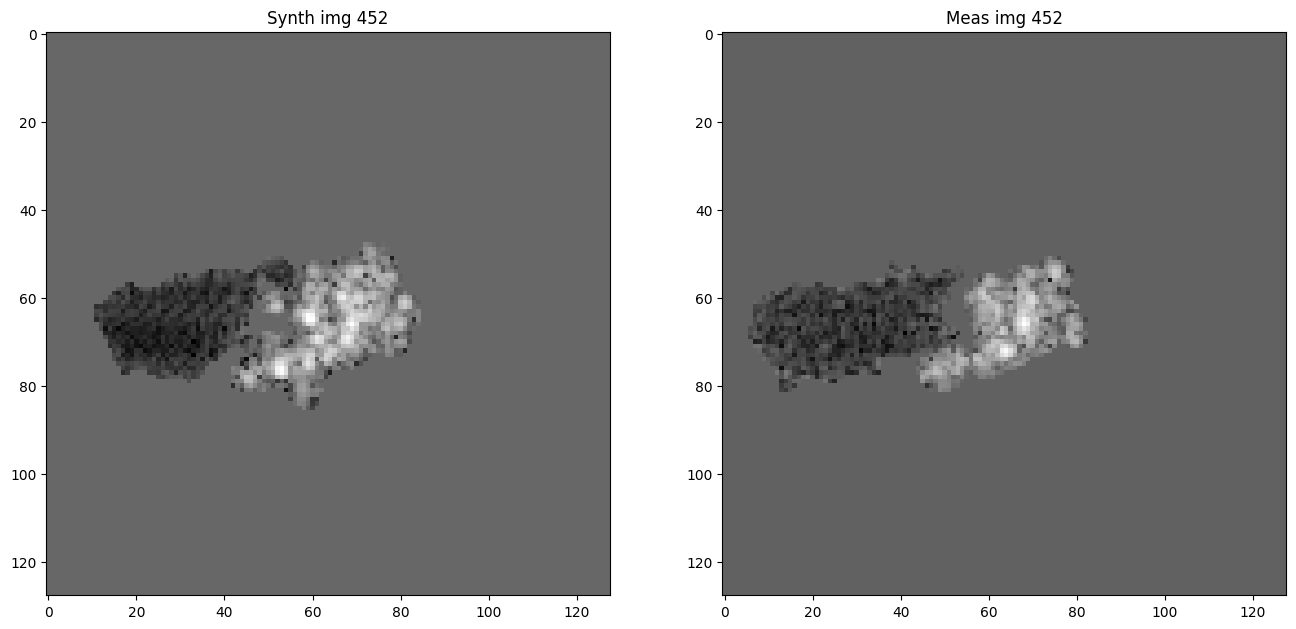

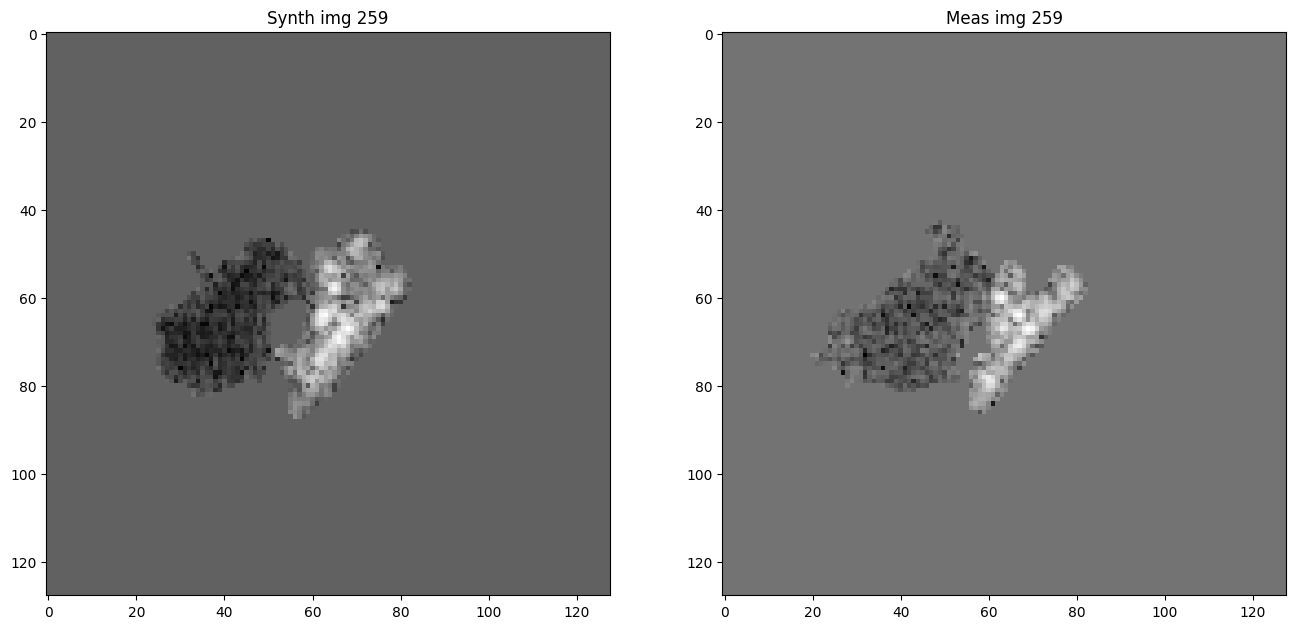

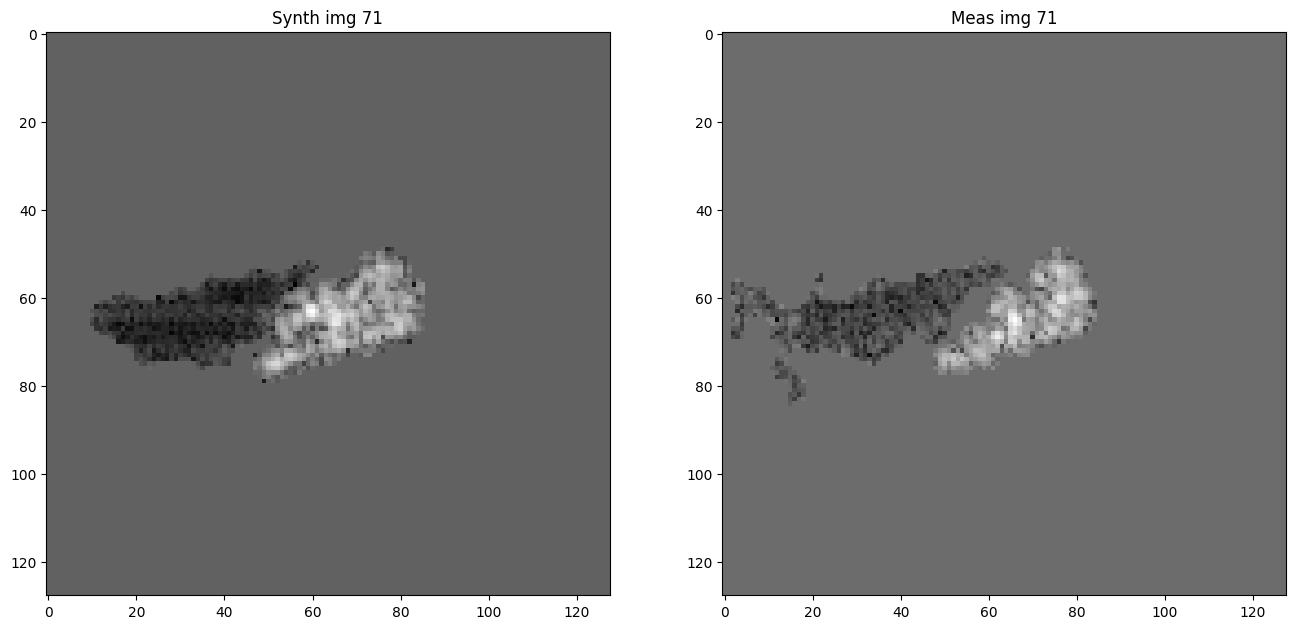

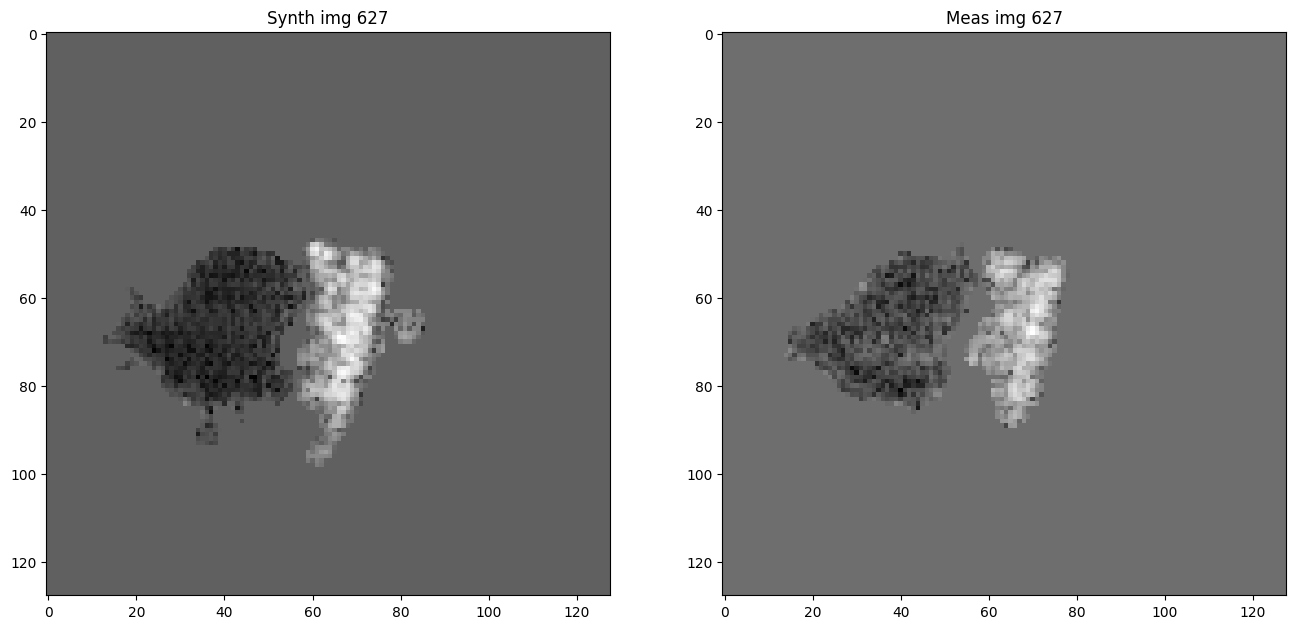

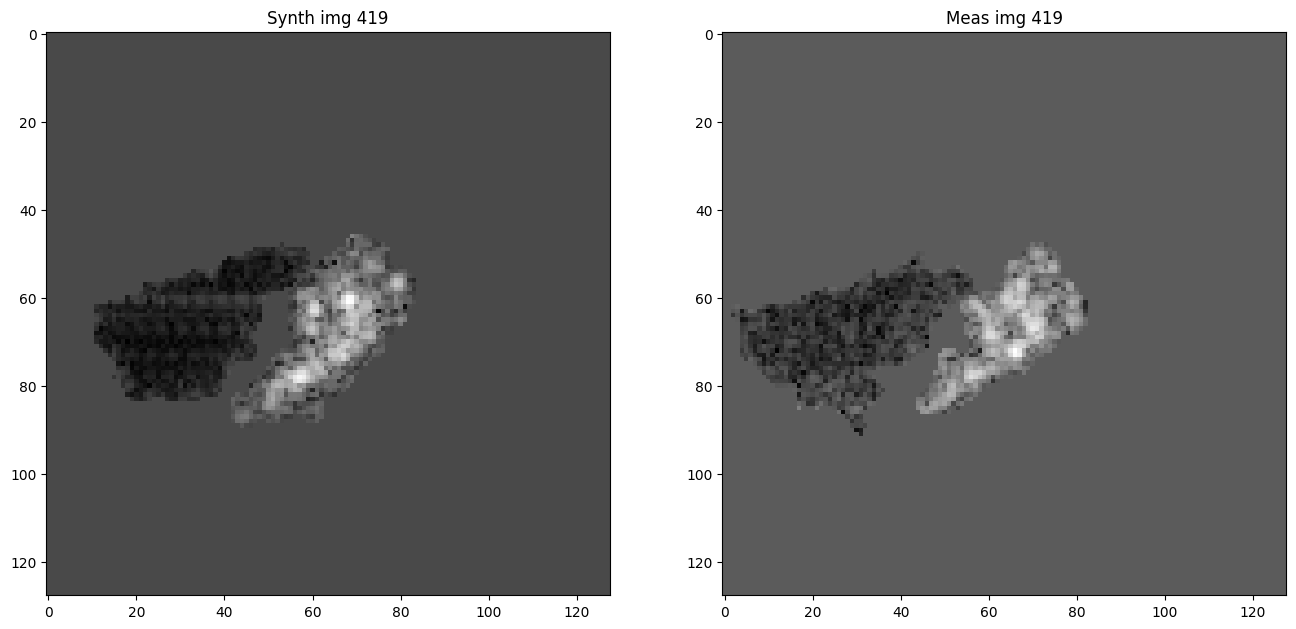

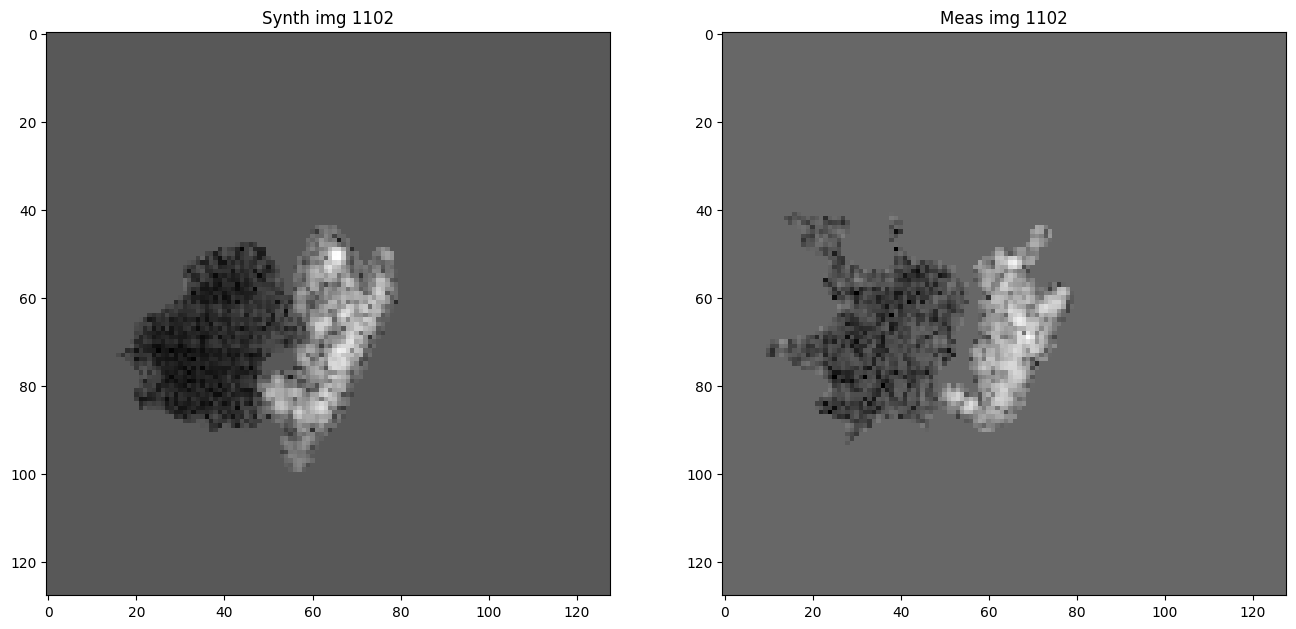

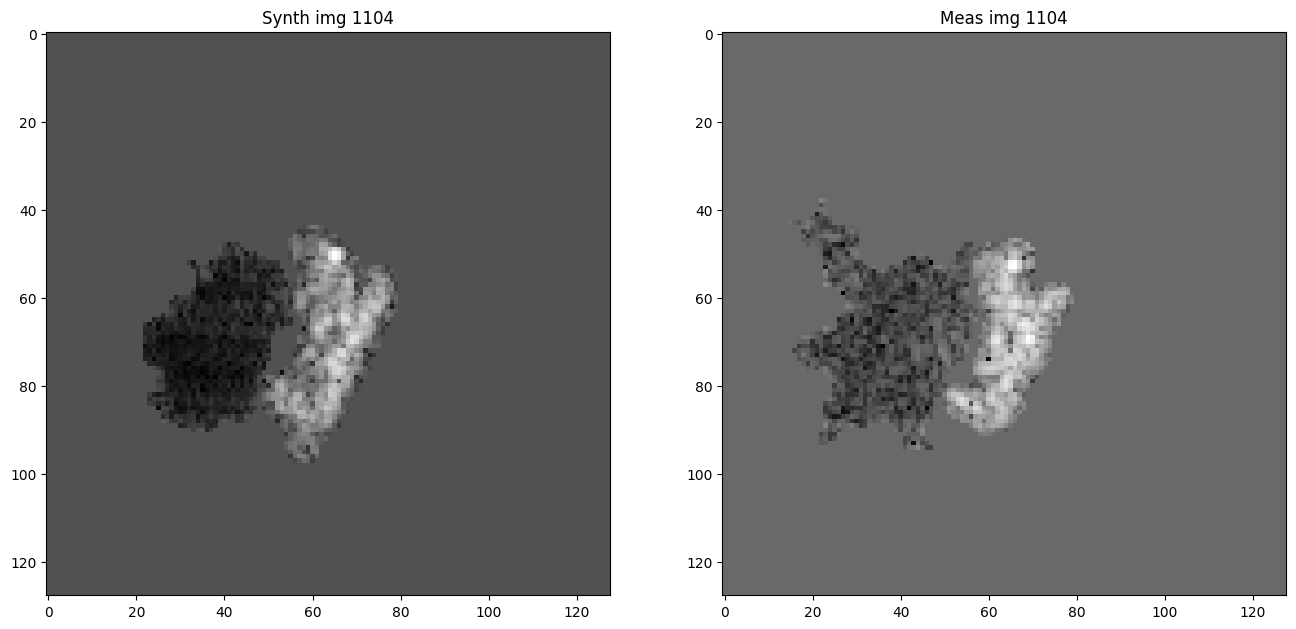

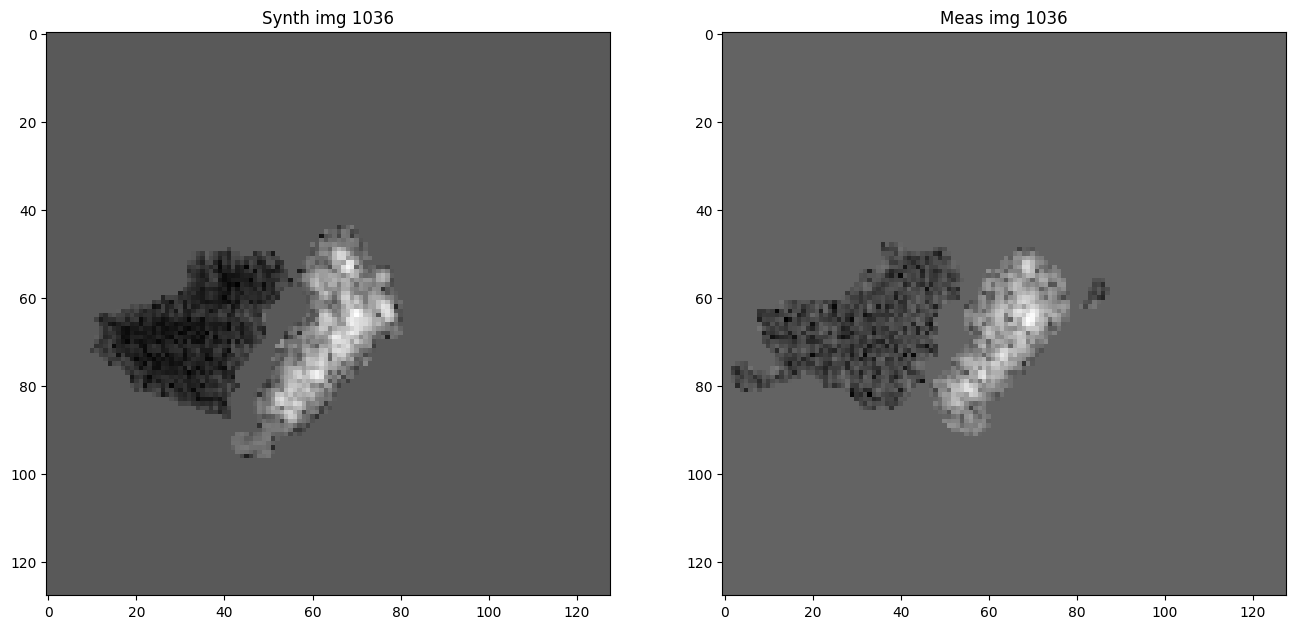

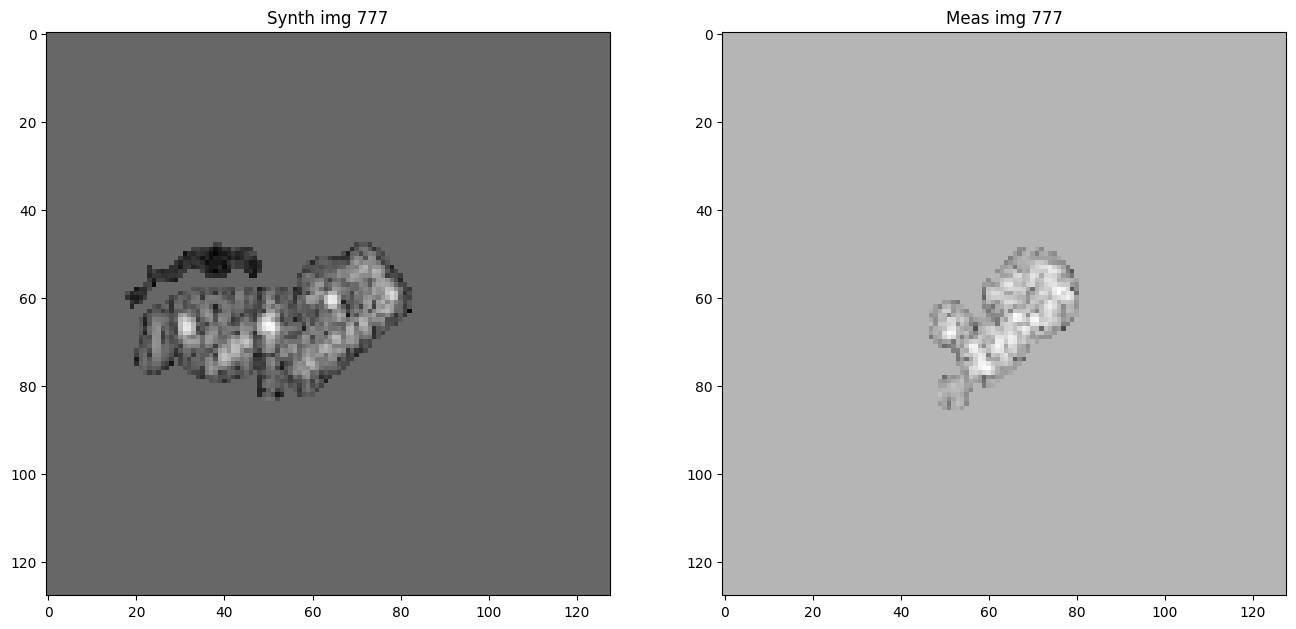

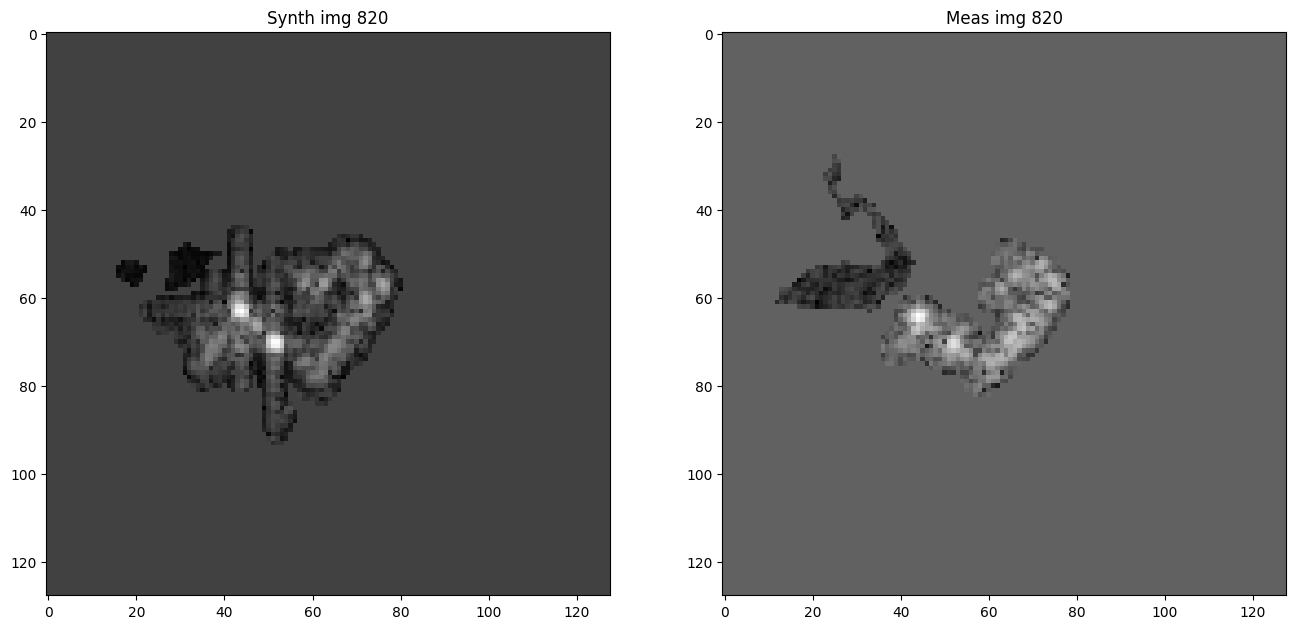

In [14]:
for i in [ 452,  259,   71,  627,  419, 1102, 1104, 1036,  777,  820]:
    synth_img = seg_mean_synth_ds[i][0][0]
    meas_img = seg_mean_meas_ds[i][0][0]

    fig = plt.figure(figsize = (16, 9))
    
    ax0 = fig.add_subplot(1, 2, 1)
    ax0.imshow(synth_img, vmin = 0, vmax = 1, cmap = "gray")
    ax0.set_title(f"Synth img {i}") 
    
    ax1 = fig.add_subplot(1, 2, 2)
    ax1.imshow(meas_img, vmin = 0, vmax = 1, cmap = "gray")
    ax1.set_title(f"Meas img {i}") 

    plt.show()

In [23]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: Seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/wo_aug/rn18_seed{seed}_b16_mean_filled.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(seg_mean_meas_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0: Seed 10
Test Accuracy: 0.8892
Evaluating Run 1: Seed 42
Test Accuracy: 0.8349
Evaluating Run 2: Seed 100
Test Accuracy: 0.8089
Evaluating Run 3: Seed 123
Test Accuracy: 0.8401
Evaluating Run 4: Seed 666
Test Accuracy: 0.8149
Evaluating Run 5: Seed 777
Test Accuracy: 0.8691
Evaluating Run 6: Seed 849
Test Accuracy: 0.7926
Evaluating Run 7: Seed 1000
Test Accuracy: 0.7777
Evaluating Run 8: Seed 1111
Test Accuracy: 0.8461
Evaluating Run 9: Seed 1234
Test Accuracy: 0.9011


In [24]:
test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Min: 77.7695
Max: 90.1115
Avg, Std: 83.7472, 3.8386


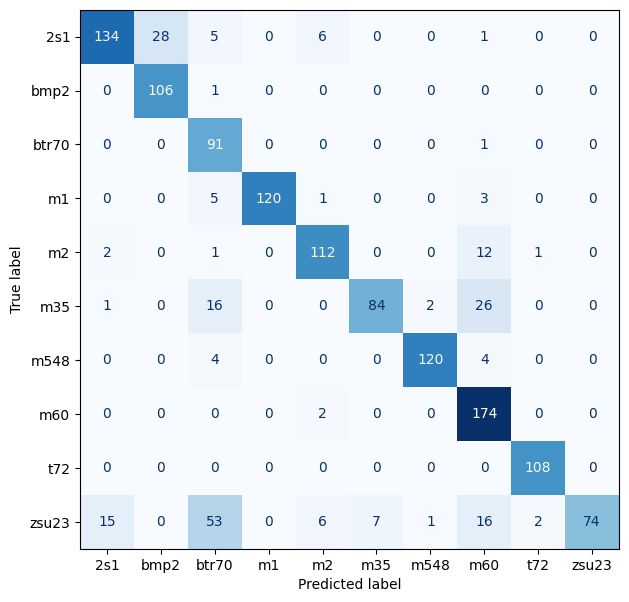

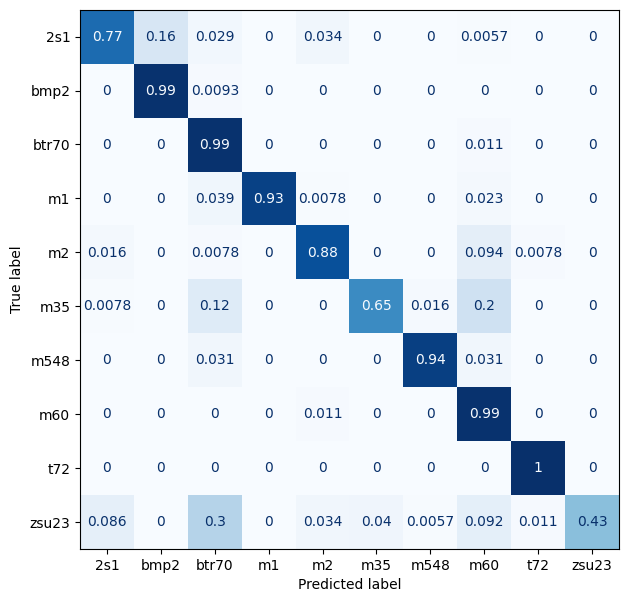

In [30]:
train_ds = seg_mean_synth_ds
test_ds = seg_mean_meas_ds

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Sequential(
    nn.Dropout(p = 0.4),
    nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
)

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/wo_aug/mean_fill/rn18_seed42_b16_mean_filled.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

labels_lst, preds_lst = [], []

with torch.no_grad():
    for inputs, labels in DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = new_model(inputs)
        _, preds = torch.max(outputs, 1)

        labels_lst.append(labels)
        preds_lst.append(preds)

_labels_all = torch.cat(labels_lst).cpu().numpy()
_preds_all = torch.cat(preds_lst).cpu().numpy()

# confusion matrix
cm = confusion_matrix(_labels_all, _preds_all)
cm_cpu  = cp.asnumpy(cm)

disp = ConfusionMatrixDisplay(cm_cpu, display_labels = train_ds.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.show()

cm_norm = confusion_matrix(_labels_all, _preds_all, normalize = "true")
cm_norm_cpu  = cp.asnumpy(cm_norm)
disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels = train_ds.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.show()

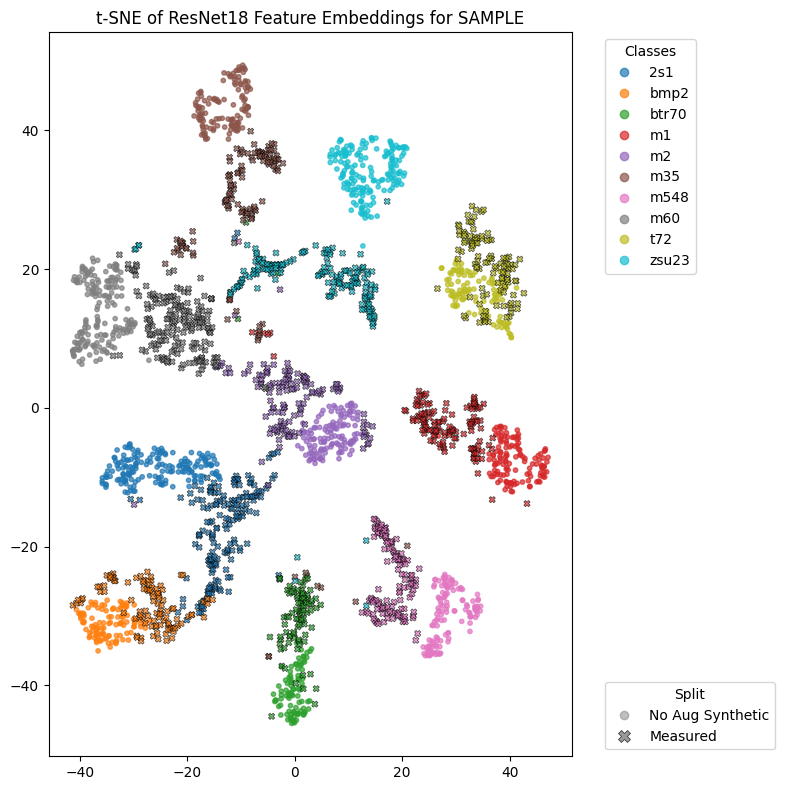

In [32]:
train_ds = seg_mean_synth_ds
test_ds = seg_mean_meas_ds

combined_ds = ConcatDataset([train_ds, test_ds])
combined_loader = DataLoader(combined_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True)

device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/wo_aug/mean_fill/rn18_seed42_b16_mean_filled.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate_method="adaptive",
    metric = "cosine"
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(train_ds), 0],
    features_2d[:len(train_ds), 1],
    c=labels_list[:len(train_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(train_ds):, 0],
    features_2d[len(train_ds):, 1],
    c=labels_list[len(train_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

[2026-05-26 19:14:31.497] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


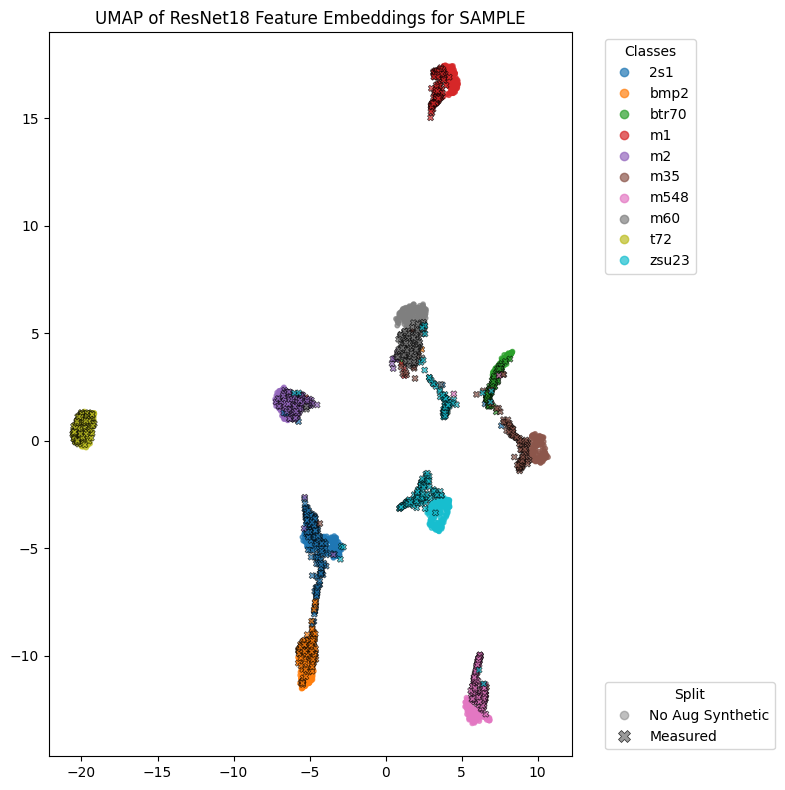

In [33]:
train_ds = seg_mean_synth_ds
test_ds = seg_mean_meas_ds

combined_ds = ConcatDataset([train_ds, test_ds])
combined_loader = DataLoader(combined_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True)

device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(meas_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/wo_aug/mean_fill/rn18_seed42_b16_mean_filled.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

reducer = UMAP(
    n_neighbors=100,
    min_dist=0.25,
    n_components=2,
    metric = "cosine"
)

features_2d_umap = reducer.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d_umap[:len(train_ds), 0],
    features_2d_umap[:len(train_ds), 1],
    c=labels_list[:len(train_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d_umap[len(train_ds):, 0],
    features_2d_umap[len(train_ds):, 1],
    c=labels_list[len(train_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

## Target only

### Fill = 0

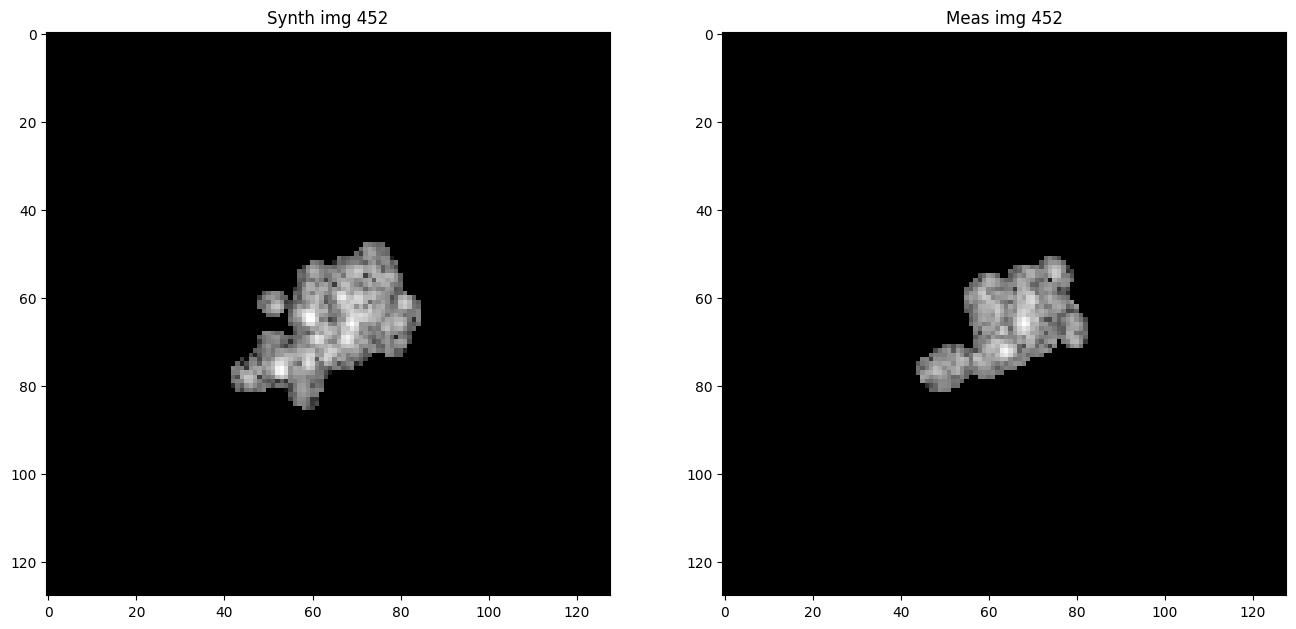

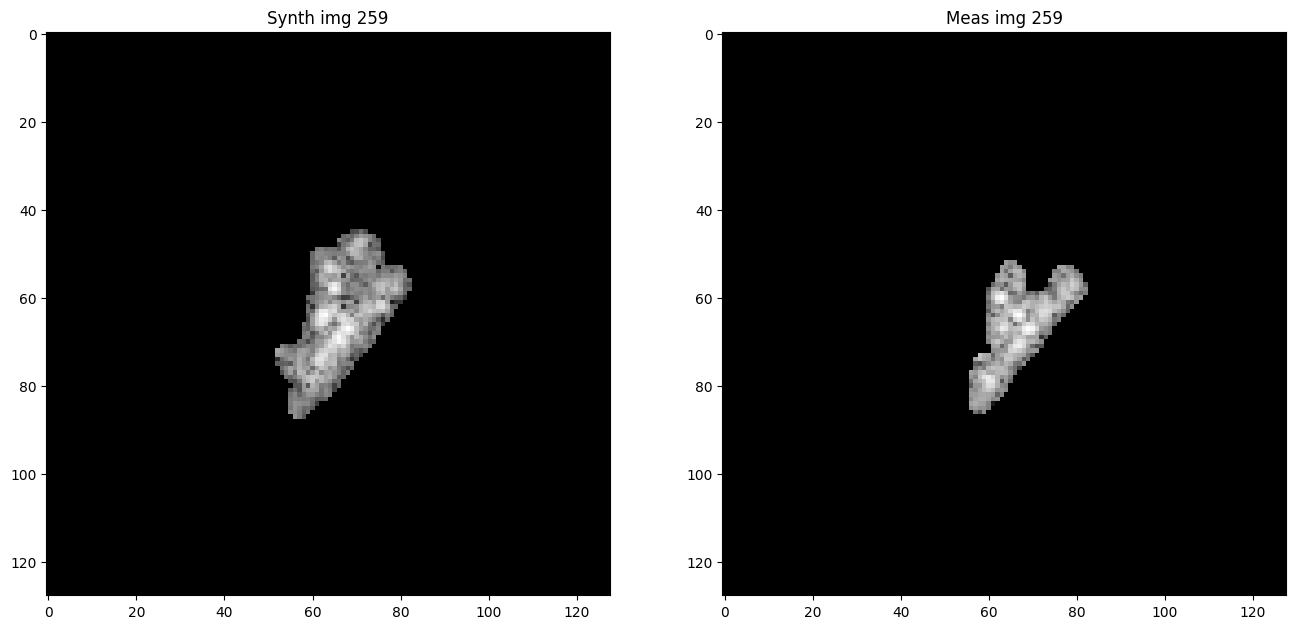

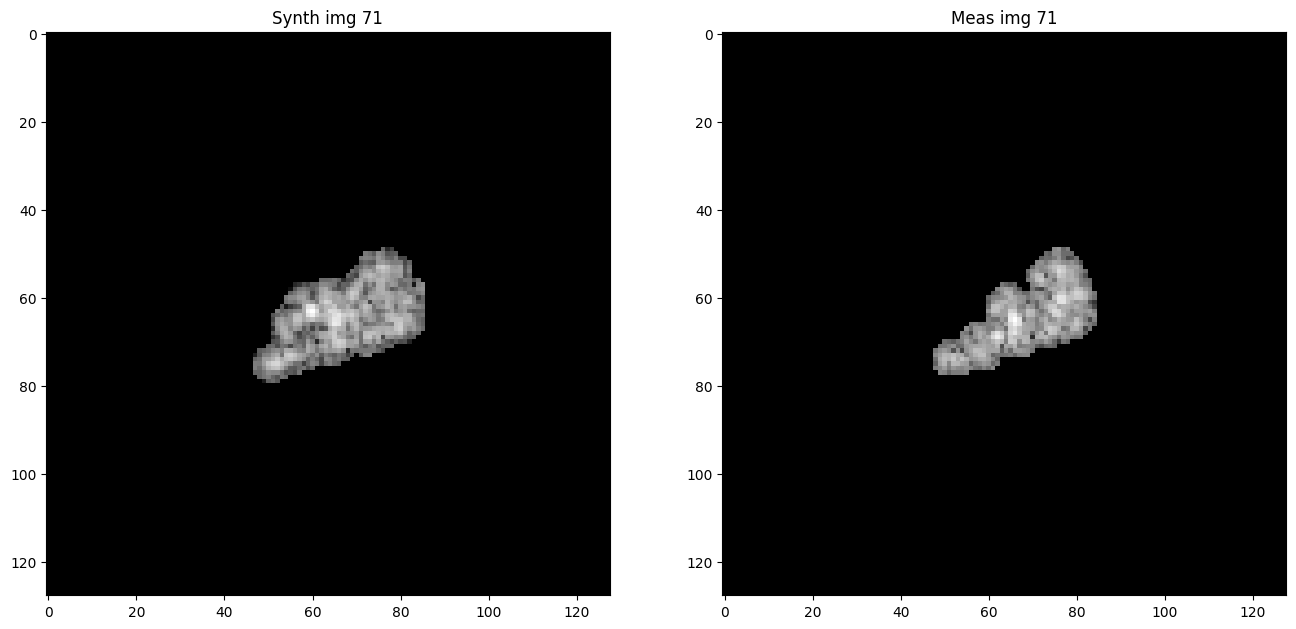

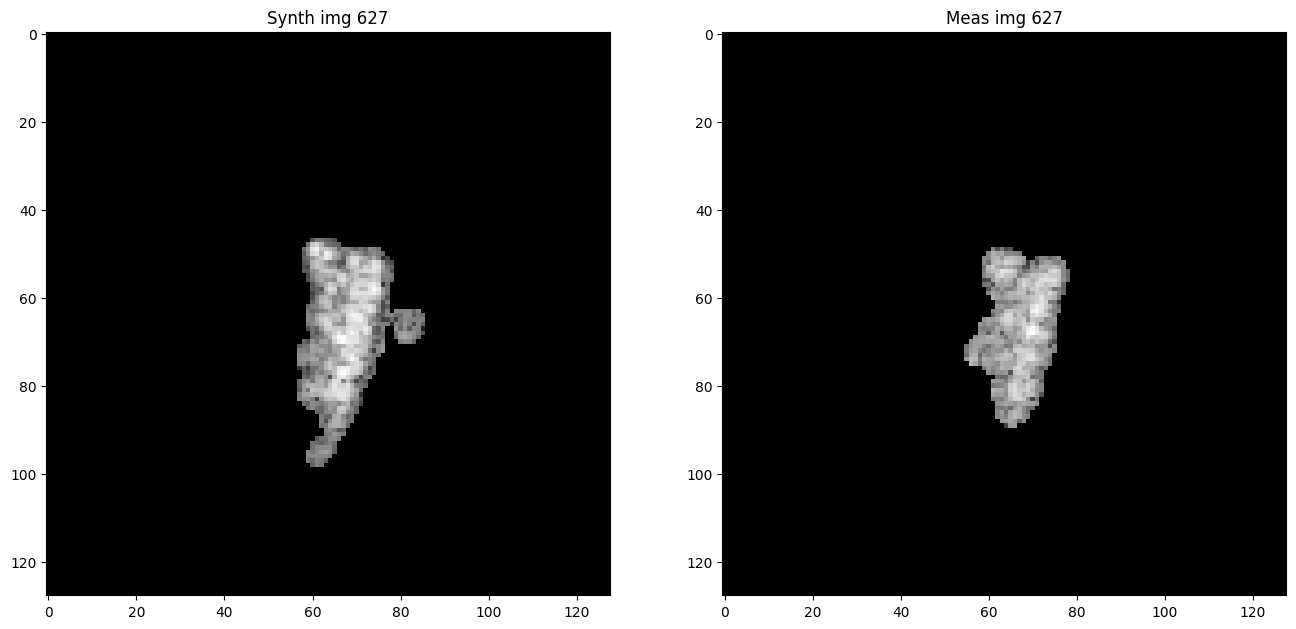

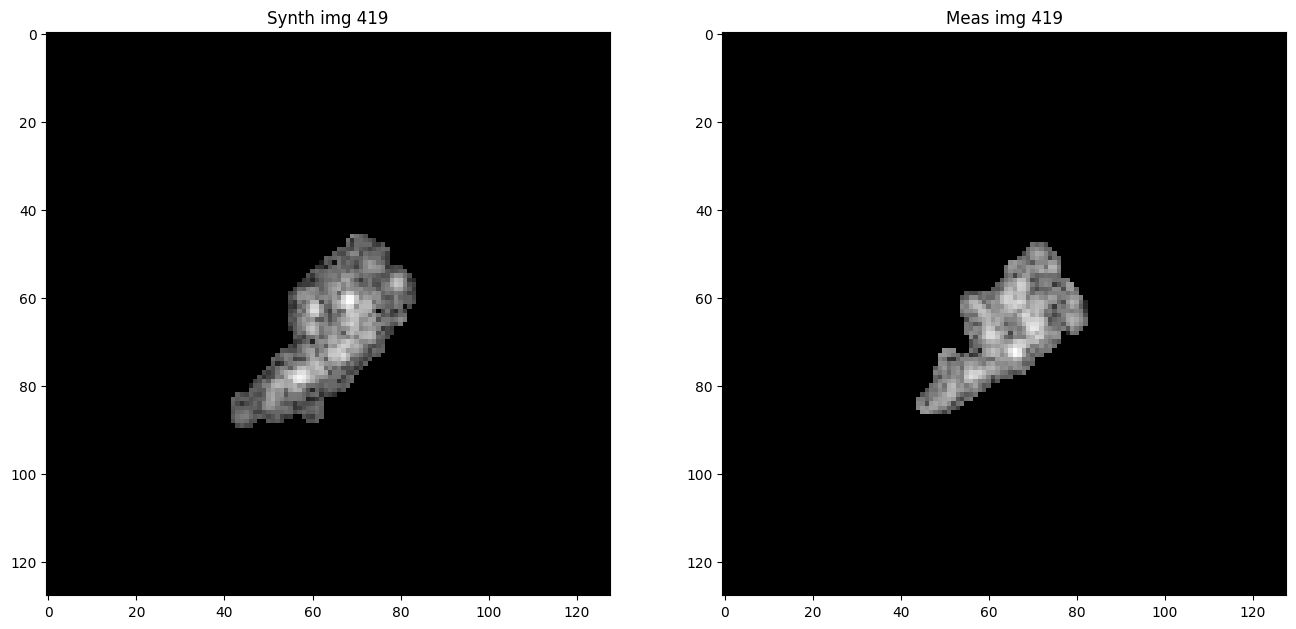

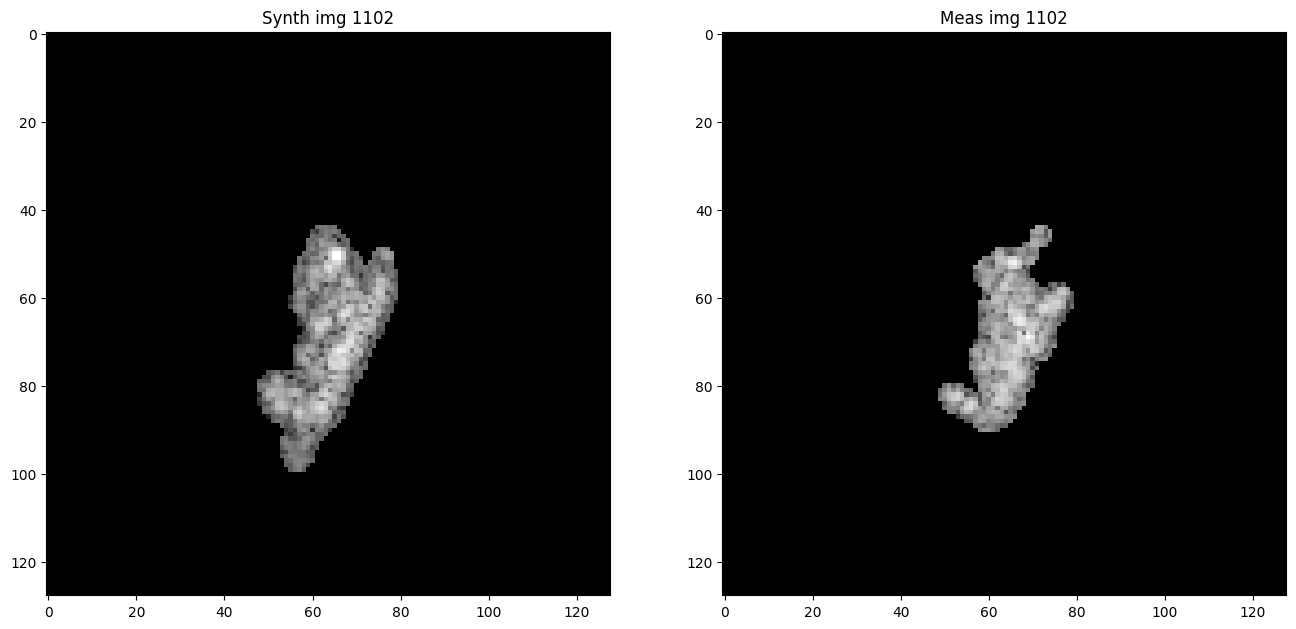

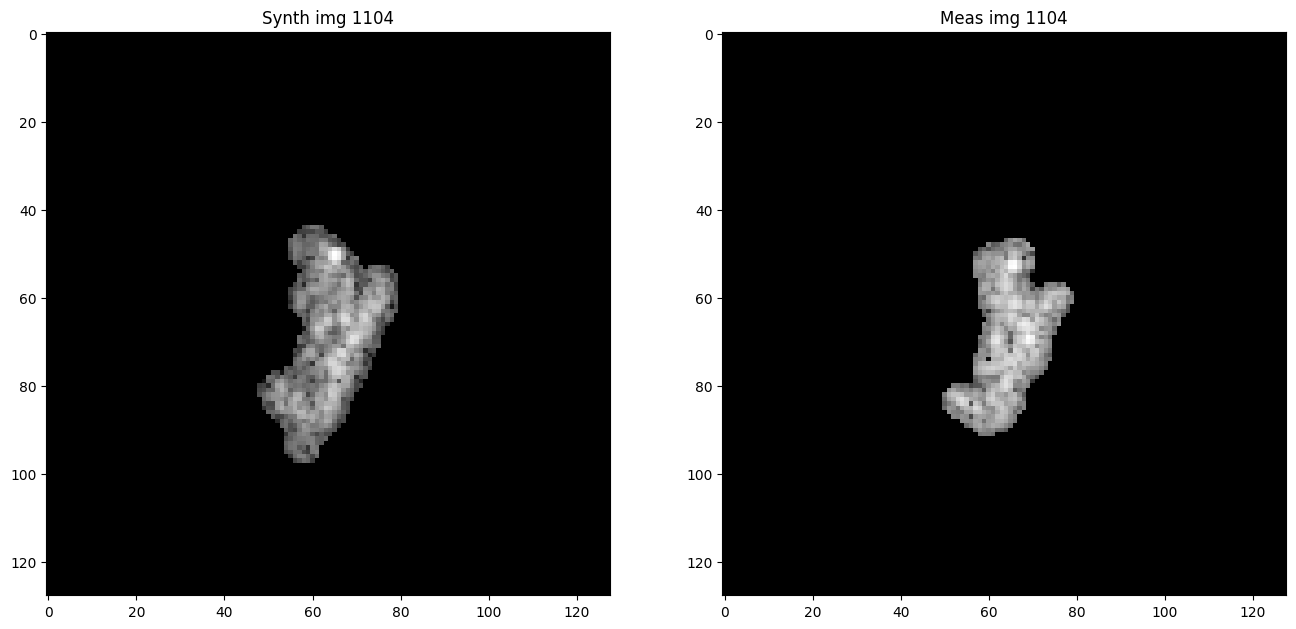

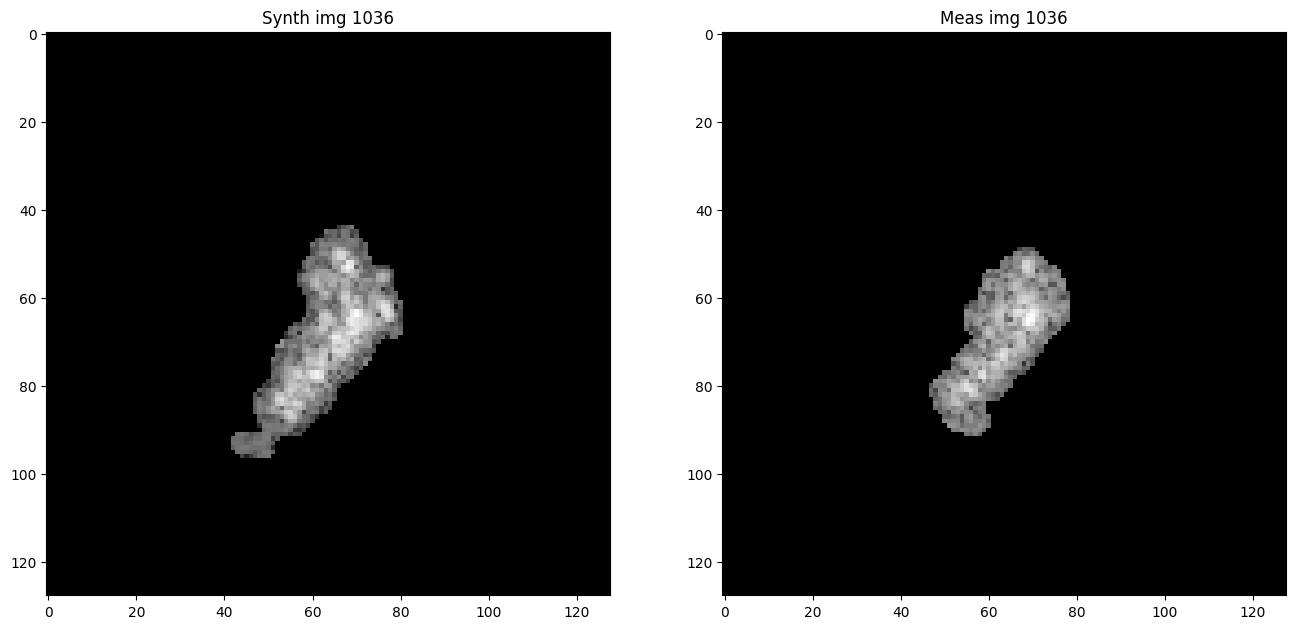

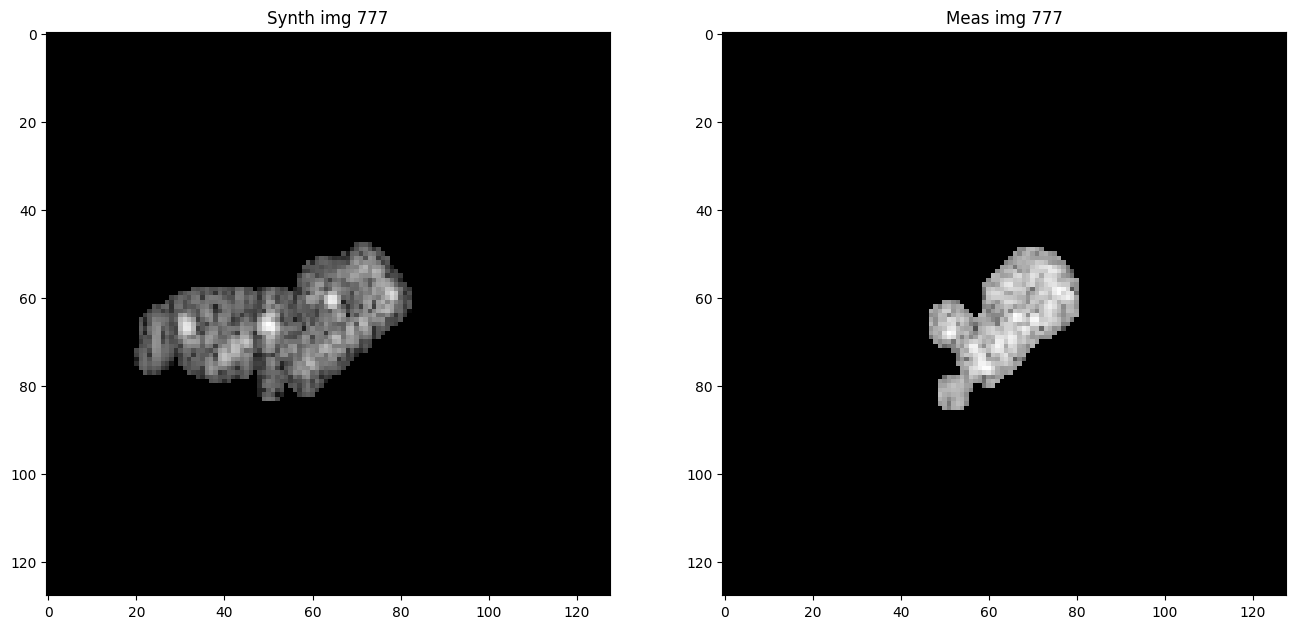

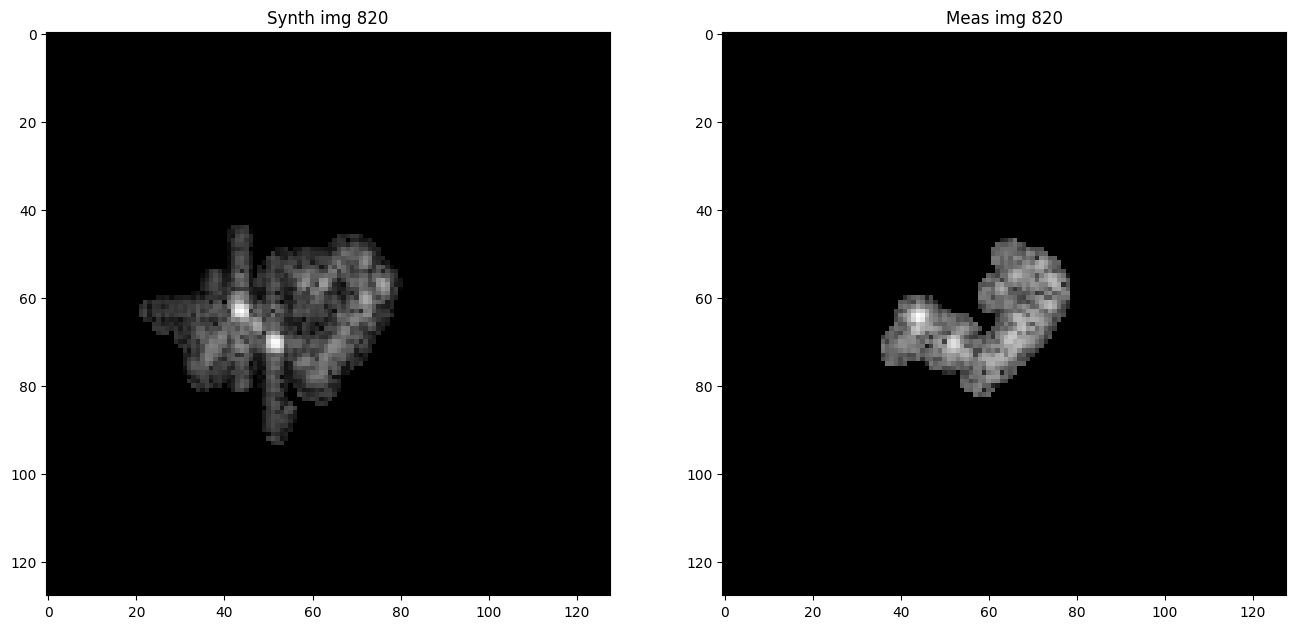

In [14]:
for i in [ 452,  259,   71,  627,  419, 1102, 1104, 1036,  777,  820]:
    synth_img = seg_target_synth_ds[i][0][0]
    meas_img = seg_target_meas_ds[i][0][0]

    fig = plt.figure(figsize = (16, 9))
    
    ax0 = fig.add_subplot(1, 2, 1)
    ax0.imshow(synth_img, vmin = 0, vmax = 1, cmap = "gray")
    ax0.set_title(f"Synth img {i}") 
    
    ax1 = fig.add_subplot(1, 2, 2)
    ax1.imshow(meas_img, vmin = 0, vmax = 1, cmap = "gray")
    ax1.set_title(f"Meas img {i}") 

    plt.show()

In [10]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: Seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/wo_aug/target_only/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(seg_target_meas_ds, batch_size=64, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0: Seed 10
Test Accuracy: 0.8052
Evaluating Run 1: Seed 42
Test Accuracy: 0.7814
Evaluating Run 2: Seed 100
Test Accuracy: 0.7710
Evaluating Run 3: Seed 123
Test Accuracy: 0.8037
Evaluating Run 4: Seed 666
Test Accuracy: 0.8015
Evaluating Run 5: Seed 777
Test Accuracy: 0.8126
Evaluating Run 6: Seed 849
Test Accuracy: 0.7896
Evaluating Run 7: Seed 1000
Test Accuracy: 0.8171
Evaluating Run 8: Seed 1111
Test Accuracy: 0.8320
Evaluating Run 9: Seed 1234
Test Accuracy: 0.8372


In [11]:
test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Min: 77.1004
Max: 83.7175
Avg, Std: 80.5130, 1.9826


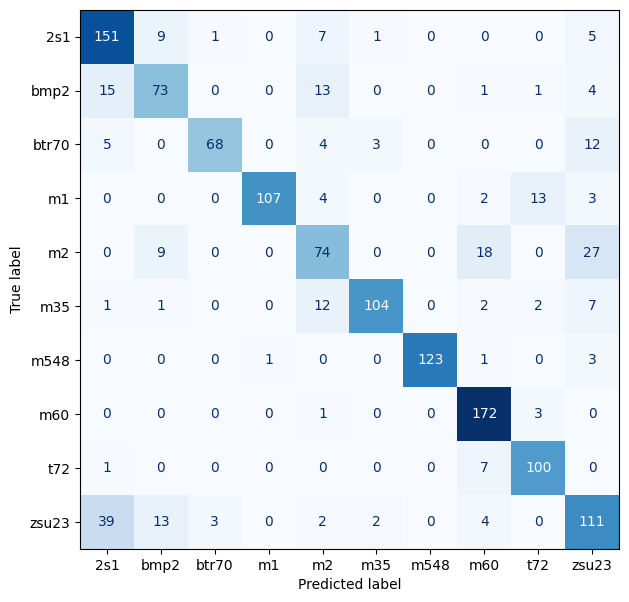

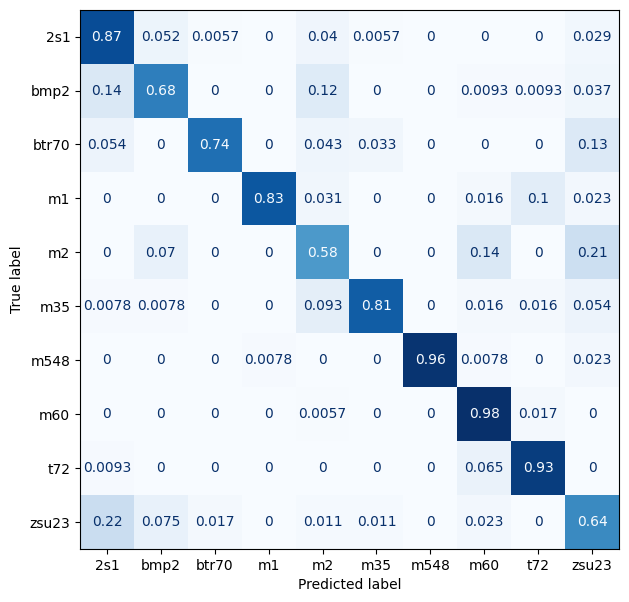

In [34]:
train_ds = seg_target_synth_ds
test_ds = seg_target_meas_ds

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Sequential(
    nn.Dropout(p = 0.4),
    nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
)

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/wo_aug/target_only/rn18_seed10_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

labels_lst, preds_lst = [], []

with torch.no_grad():
    for inputs, labels in DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = new_model(inputs)
        _, preds = torch.max(outputs, 1)

        labels_lst.append(labels)
        preds_lst.append(preds)

_labels_all = torch.cat(labels_lst).cpu().numpy()
_preds_all = torch.cat(preds_lst).cpu().numpy()

# confusion matrix
cm = confusion_matrix(_labels_all, _preds_all)
cm_cpu  = cp.asnumpy(cm)

disp = ConfusionMatrixDisplay(cm_cpu, display_labels = train_ds.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.show()

cm_norm = confusion_matrix(_labels_all, _preds_all, normalize = "true")
cm_norm_cpu  = cp.asnumpy(cm_norm)
disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels = train_ds.classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.show()

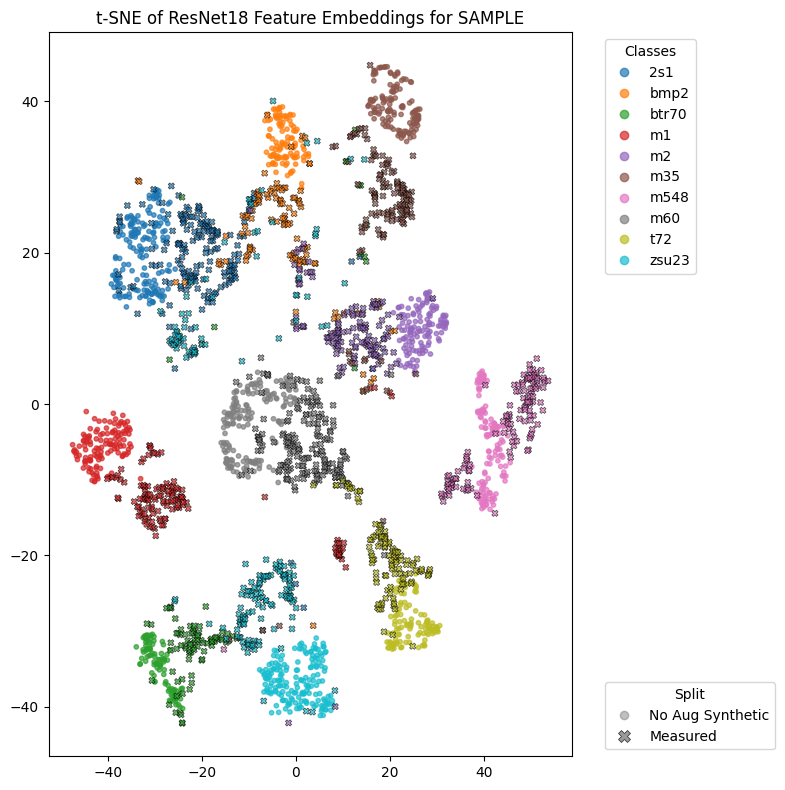

In [35]:
train_ds = seg_target_synth_ds
test_ds = seg_target_meas_ds

combined_ds = ConcatDataset([train_ds, test_ds])
combined_loader = DataLoader(combined_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True)

device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/wo_aug/target_only/rn18_seed10_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate_method="adaptive",
    metric = "cosine"
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(train_ds), 0],
    features_2d[:len(train_ds), 1],
    c=labels_list[:len(train_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(train_ds):, 0],
    features_2d[len(train_ds):, 1],
    c=labels_list[len(train_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

[2026-05-26 19:22:23.839] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


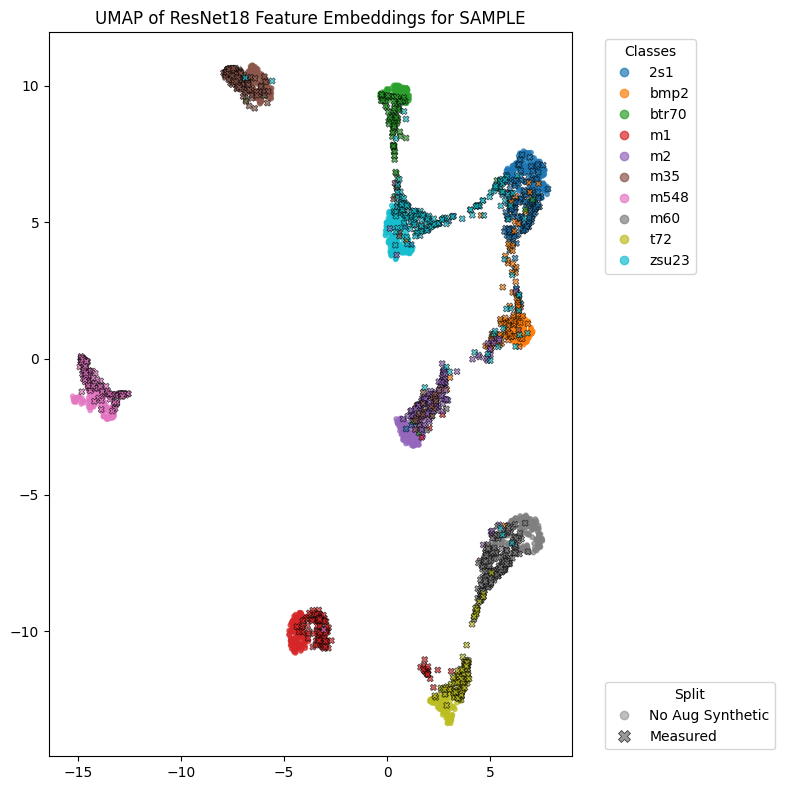

In [36]:
train_ds = seg_target_synth_ds
test_ds = seg_target_meas_ds

combined_ds = ConcatDataset([train_ds, test_ds])
combined_loader = DataLoader(combined_ds, batch_size=64, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True)

device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(meas_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/wo_aug/target_only/rn18_seed10_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

reducer = UMAP(
    n_neighbors=100,
    min_dist=0.25,
    n_components=2,
    metric = "cosine"
)

features_2d_umap = reducer.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d_umap[:len(train_ds), 0],
    features_2d_umap[:len(train_ds), 1],
    c=labels_list[:len(train_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d_umap[len(train_ds):, 0],
    features_2d_umap[len(train_ds):, 1],
    c=labels_list[len(train_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()